#  Analisando Dados de Preços de Casas nos EUA
### FAESA Centro Universitário — Analise de dados
**Dataset:** [House Prices - Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)

---
##  Índice
1. [Configuração e Importações](#1-configuração-e-importações)
2. [Análise Exploratória de Dados (EDA)](#2-análise-exploratória-de-dados-eda)
3. [Feature Engineering](#3-feature-engineering)
4. [Aprendizagem Supervisionada — Regressão](#4-aprendizagem-supervisionada--regressão)
5. [Aprendizagem Supervisionada — Classificação](#5-aprendizagem-supervisionada--classificação)
6. [Aprendizagem Não Supervisionada](#6-aprendizagem-não-supervisionada)
7. [Métricas e Comparação dos Modelos](#7-métricas-e-comparação-dos-modelos)
8. [Conclusões](#8-conclusões)

In [22]:
# ── Instalação de dependências (caso necessário) ──────────────────────────────
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost mlxtend

# ── Bibliotecas gerais ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualização ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Pré-processamento ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Modelos supervisionados ───────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from xgboost import XGBRegressor, XGBClassifier

# ── Modelos não supervisionados ───────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Configurações de estilo ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
SEED = 42

print('✅ Todas as bibliotecas importadas com sucesso!')

✅ Todas as bibliotecas importadas com sucesso!


---
## 1. Configuração e Importações

In [23]:
# ── Carregamento dos dados ────────────────────────────────────────────────────
# Certifique-se de que train.csv e test.csv estão na mesma pasta do notebook
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train: {train.shape[0]} linhas × {train.shape[1]} colunas')
print(f'Test:  {test.shape[0]} linhas × {test.shape[1]} colunas')
train.head()

Train: 1460 linhas × 81 colunas
Test:  1459 linhas × 80 colunas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 2. Análise Exploratória de Dados (EDA)

In [24]:
# ── Visão geral do dataset ────────────────────────────────────────────────────
print('=== INFORMAÇÕES GERAIS ===')
train.info()

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-n

In [25]:
# ── Estatísticas descritivas ──────────────────────────────────────────────────
print('=== ESTATÍSTICAS DESCRITIVAS (variáveis numéricas) ===')
train.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

=== ESTATÍSTICAS DESCRITIVAS (variáveis numéricas) ===


,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


              Qtd Faltante  % Faltante
PoolQC                1453       99.52
MiscFeature           1406       96.30
Alley                 1369       93.77
Fence                 1179       80.75
MasVnrType             872       59.73
FireplaceQu            690       47.26
LotFrontage            259       17.74
GarageType              81        5.55
GarageYrBlt             81        5.55
GarageFinish            81        5.55
GarageQual              81        5.55
GarageCond              81        5.55
BsmtFinType2            38        2.60
BsmtExposure            38        2.60
BsmtFinType1            37        2.53
BsmtCond                37        2.53
BsmtQual                37        2.53
MasVnrArea               8        0.55
Electrical               1        0.07


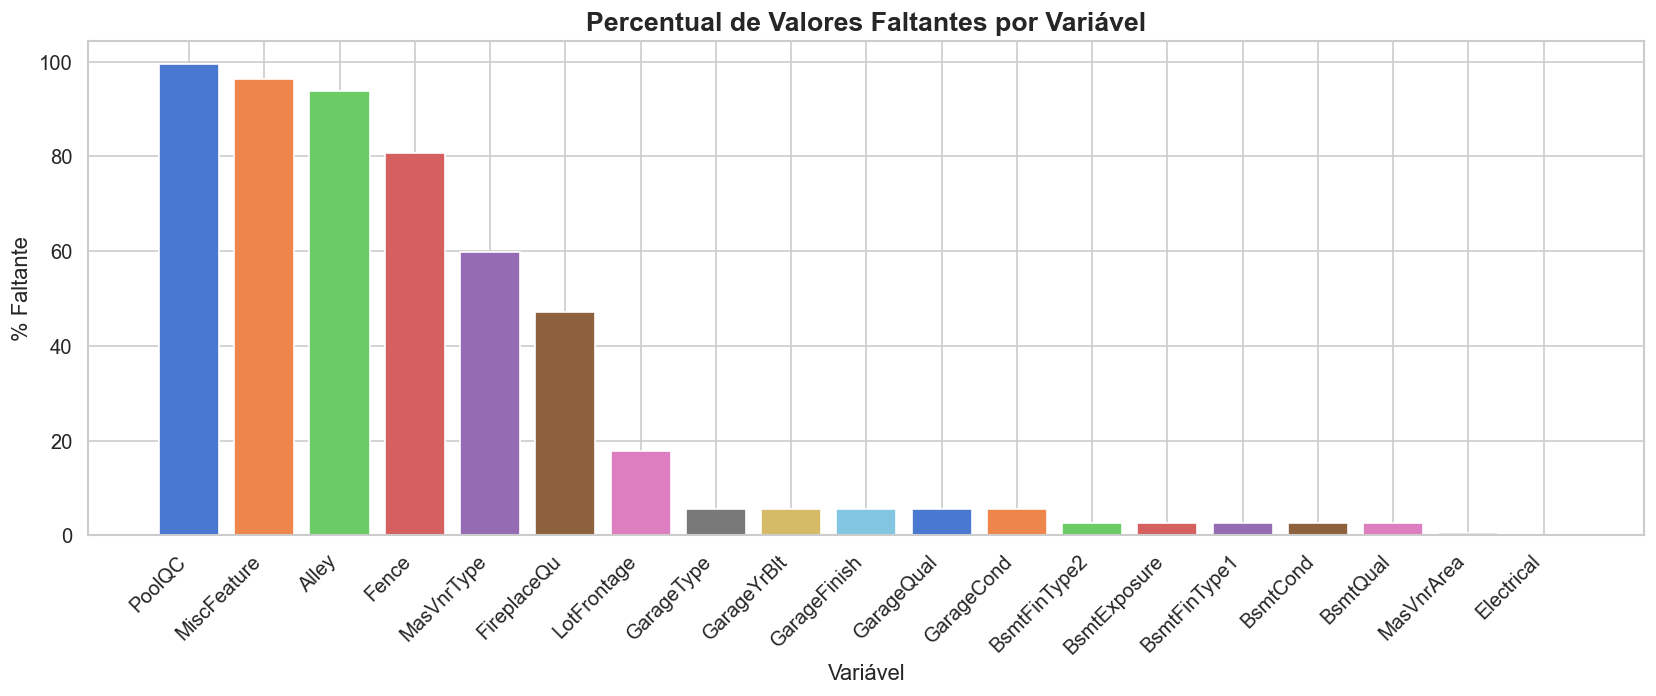

In [26]:
# ── Valores faltantes ─────────────────────────────────────────────────────────
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({'Qtd Faltante': missing, '% Faltante': missing_pct})
print(missing_df)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(missing_df.index, missing_df['% Faltante'], color=sns.color_palette('muted', len(missing_df)))
ax.set_title('Percentual de Valores Faltantes por Variável', fontsize=16, fontweight='bold')
ax.set_ylabel('% Faltante')
ax.set_xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

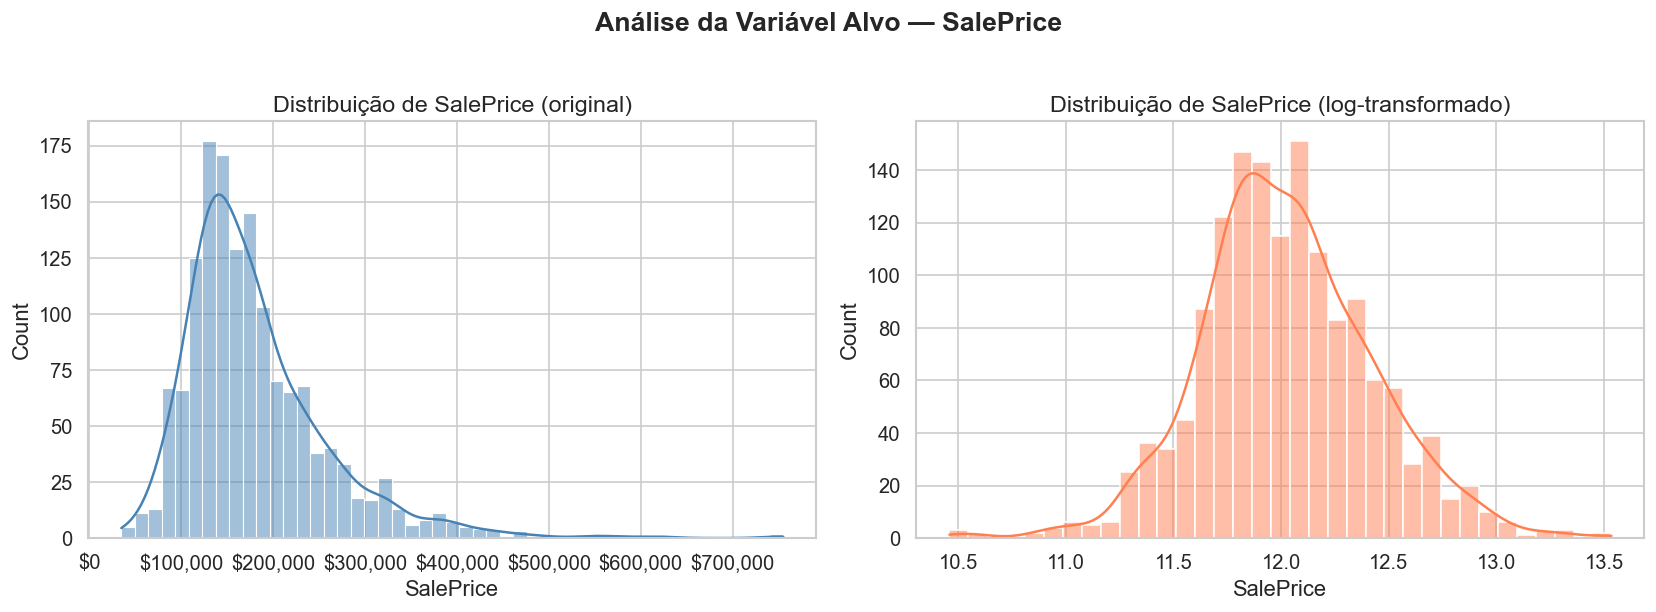

Skewness original:       1.883
Skewness log-transform:  0.121


In [27]:
# ── Distribuição da variável alvo: SalePrice ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de SalePrice (original)', fontsize=14)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Distribuição log-transformada
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribuição de SalePrice (log-transformado)', fontsize=14)

plt.suptitle('Análise da Variável Alvo — SalePrice', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Skewness original:       {train["SalePrice"].skew():.3f}')
print(f'Skewness log-transform:  {np.log1p(train["SalePrice"]).skew():.3f}')

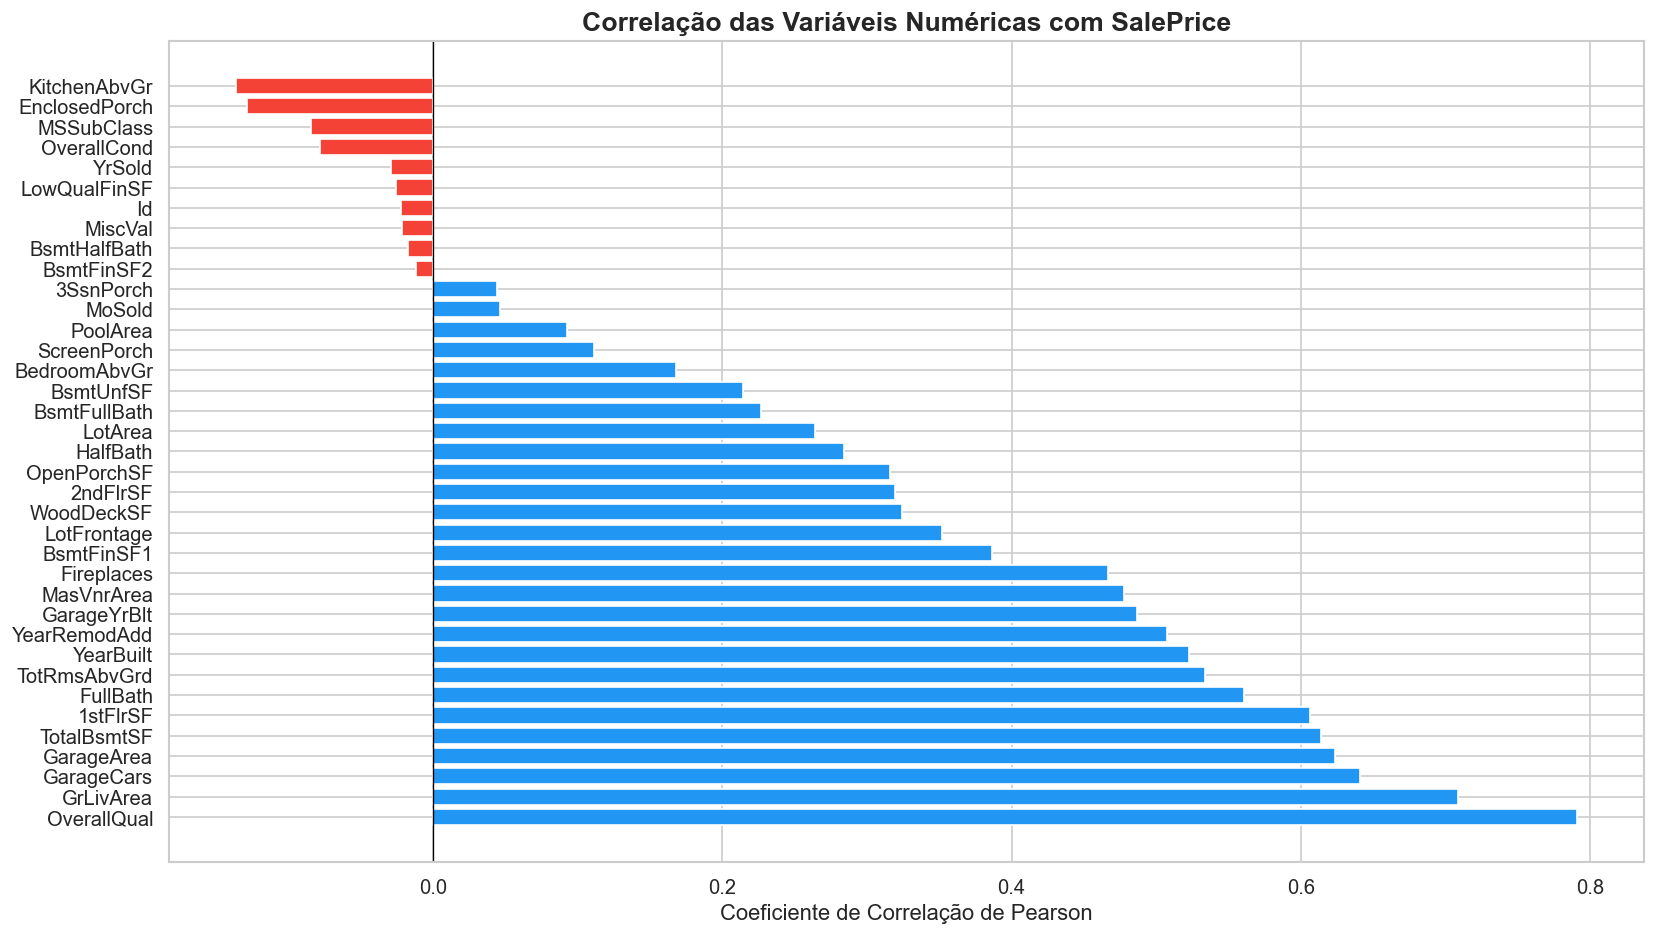

In [28]:
# ── Correlações com SalePrice ─────────────────────────────────────────────────
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação das Variáveis Numéricas com SalePrice', fontsize=16, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação de Pearson')
plt.tight_layout()
plt.show()

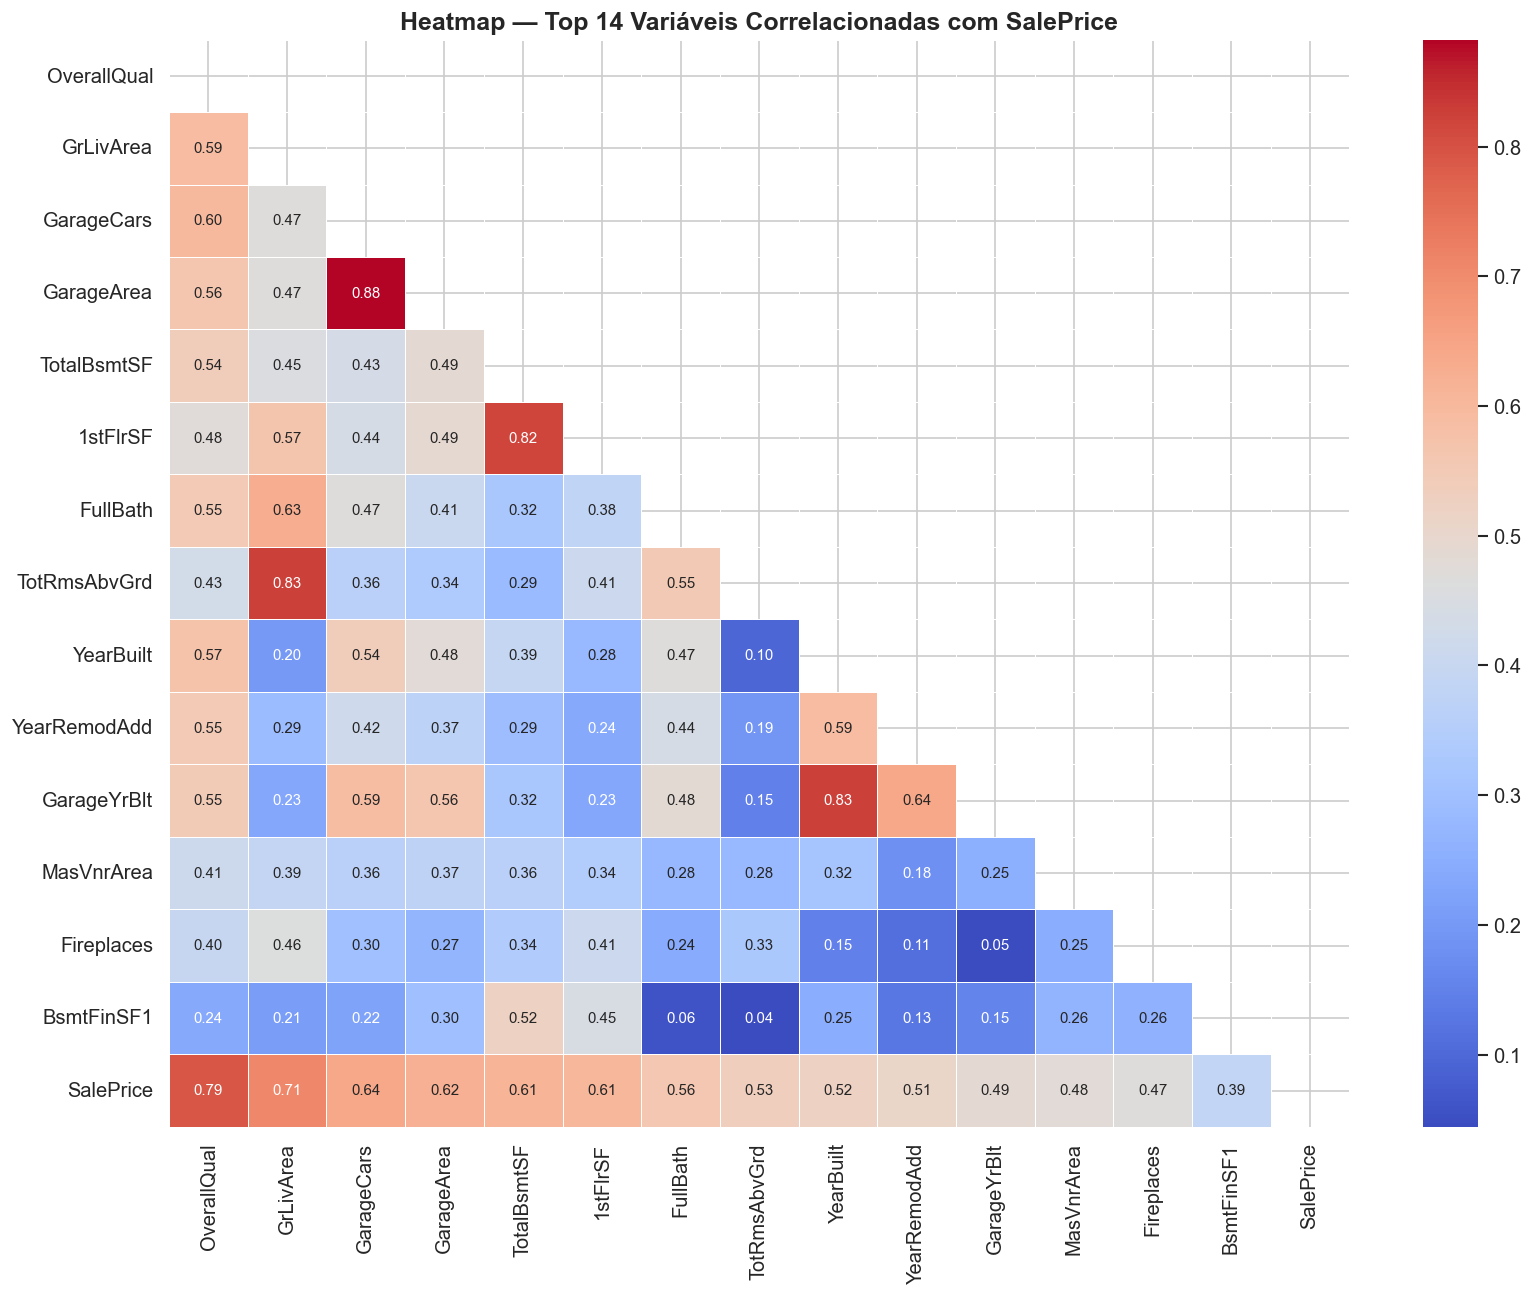

In [29]:
# ── Heatmap das top 15 correlações ───────────────────────────────────────────
top_features = corr.abs().nlargest(14).index.tolist() + ['SalePrice']

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(train[top_features].corr(), dtype=bool))
sns.heatmap(
    train[top_features].corr(),
    mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Heatmap — Top 14 Variáveis Correlacionadas com SalePrice', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

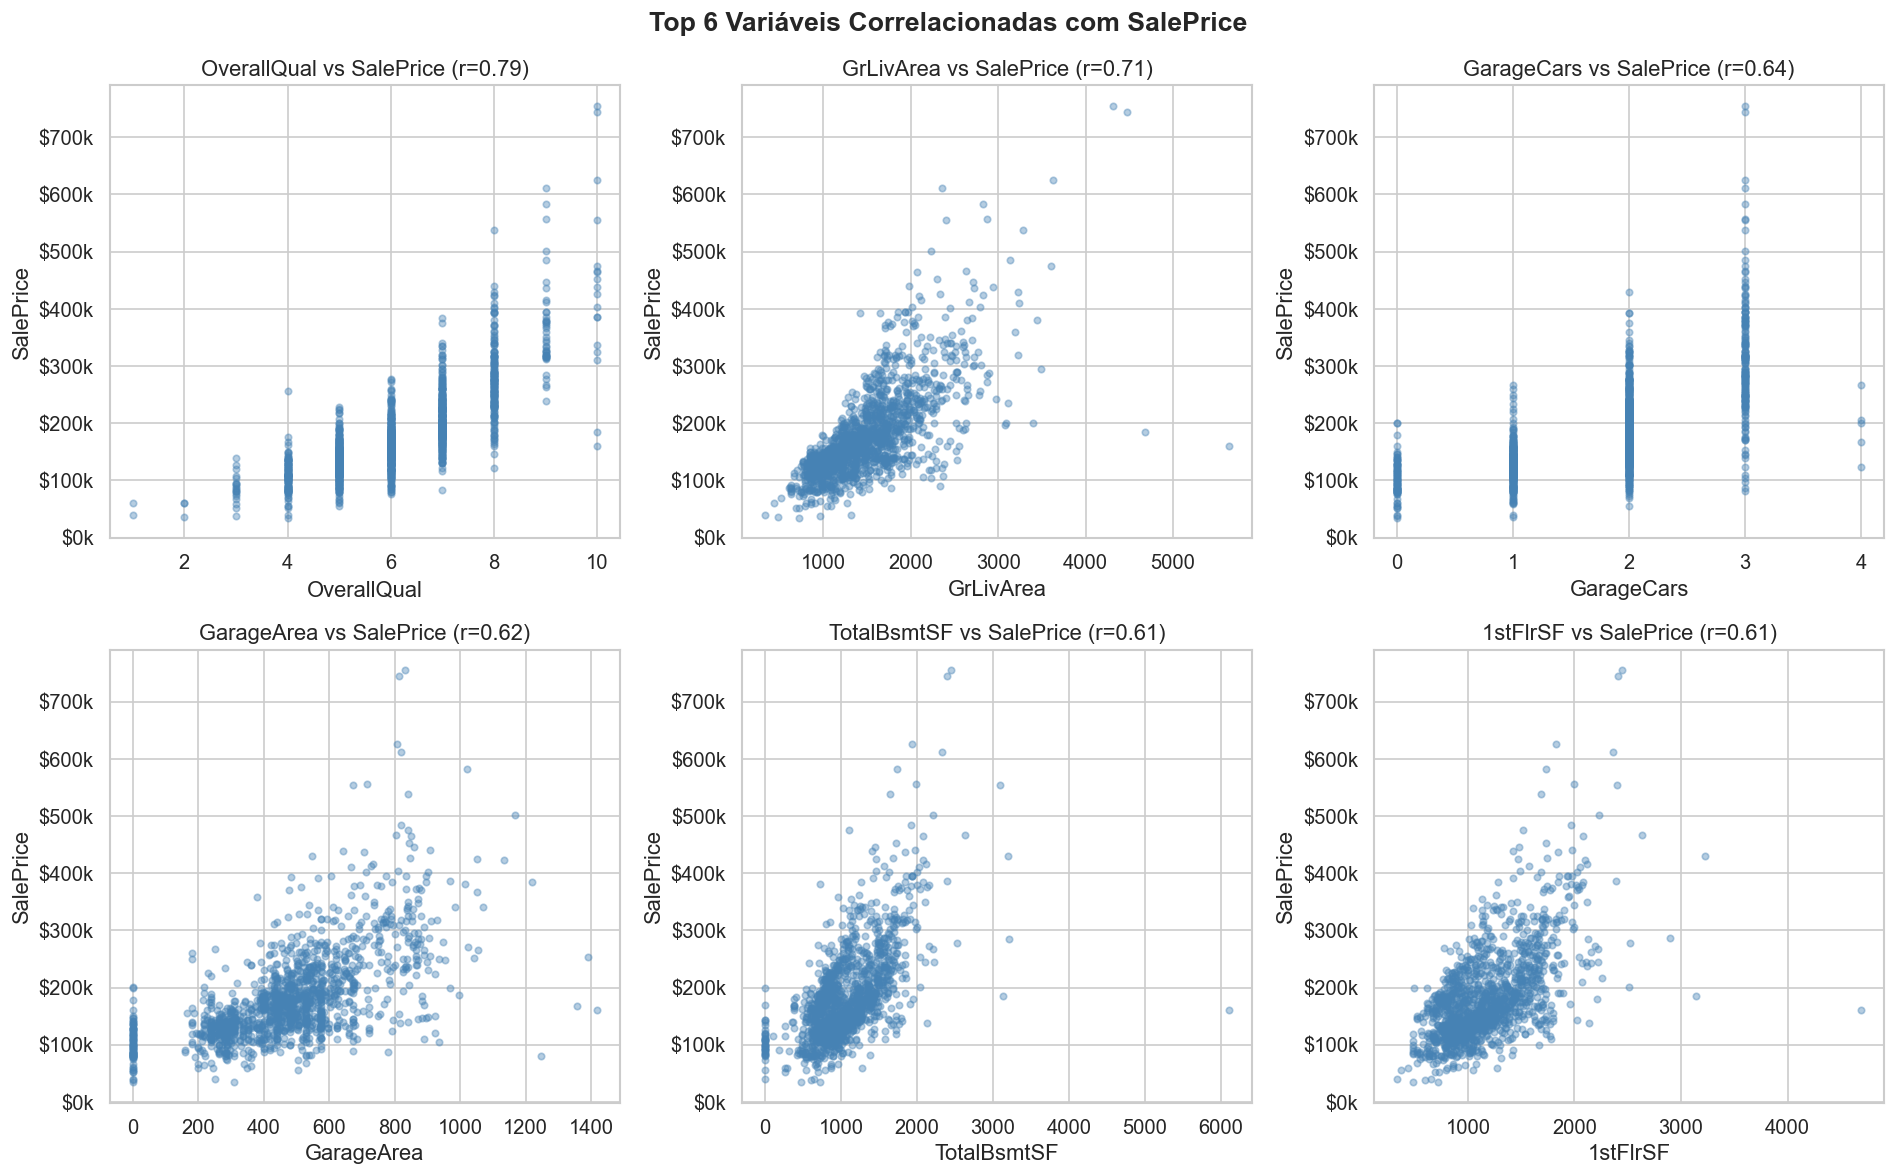

In [30]:
# ── Scatter plots: top correlações positivas ──────────────────────────────────
top_pos = corr.nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), top_pos):
    ax.scatter(train[col], train['SalePrice'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{col} vs SalePrice (r={train[col].corr(train["SalePrice"]):.2f})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.suptitle('Top 6 Variáveis Correlacionadas com SalePrice', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

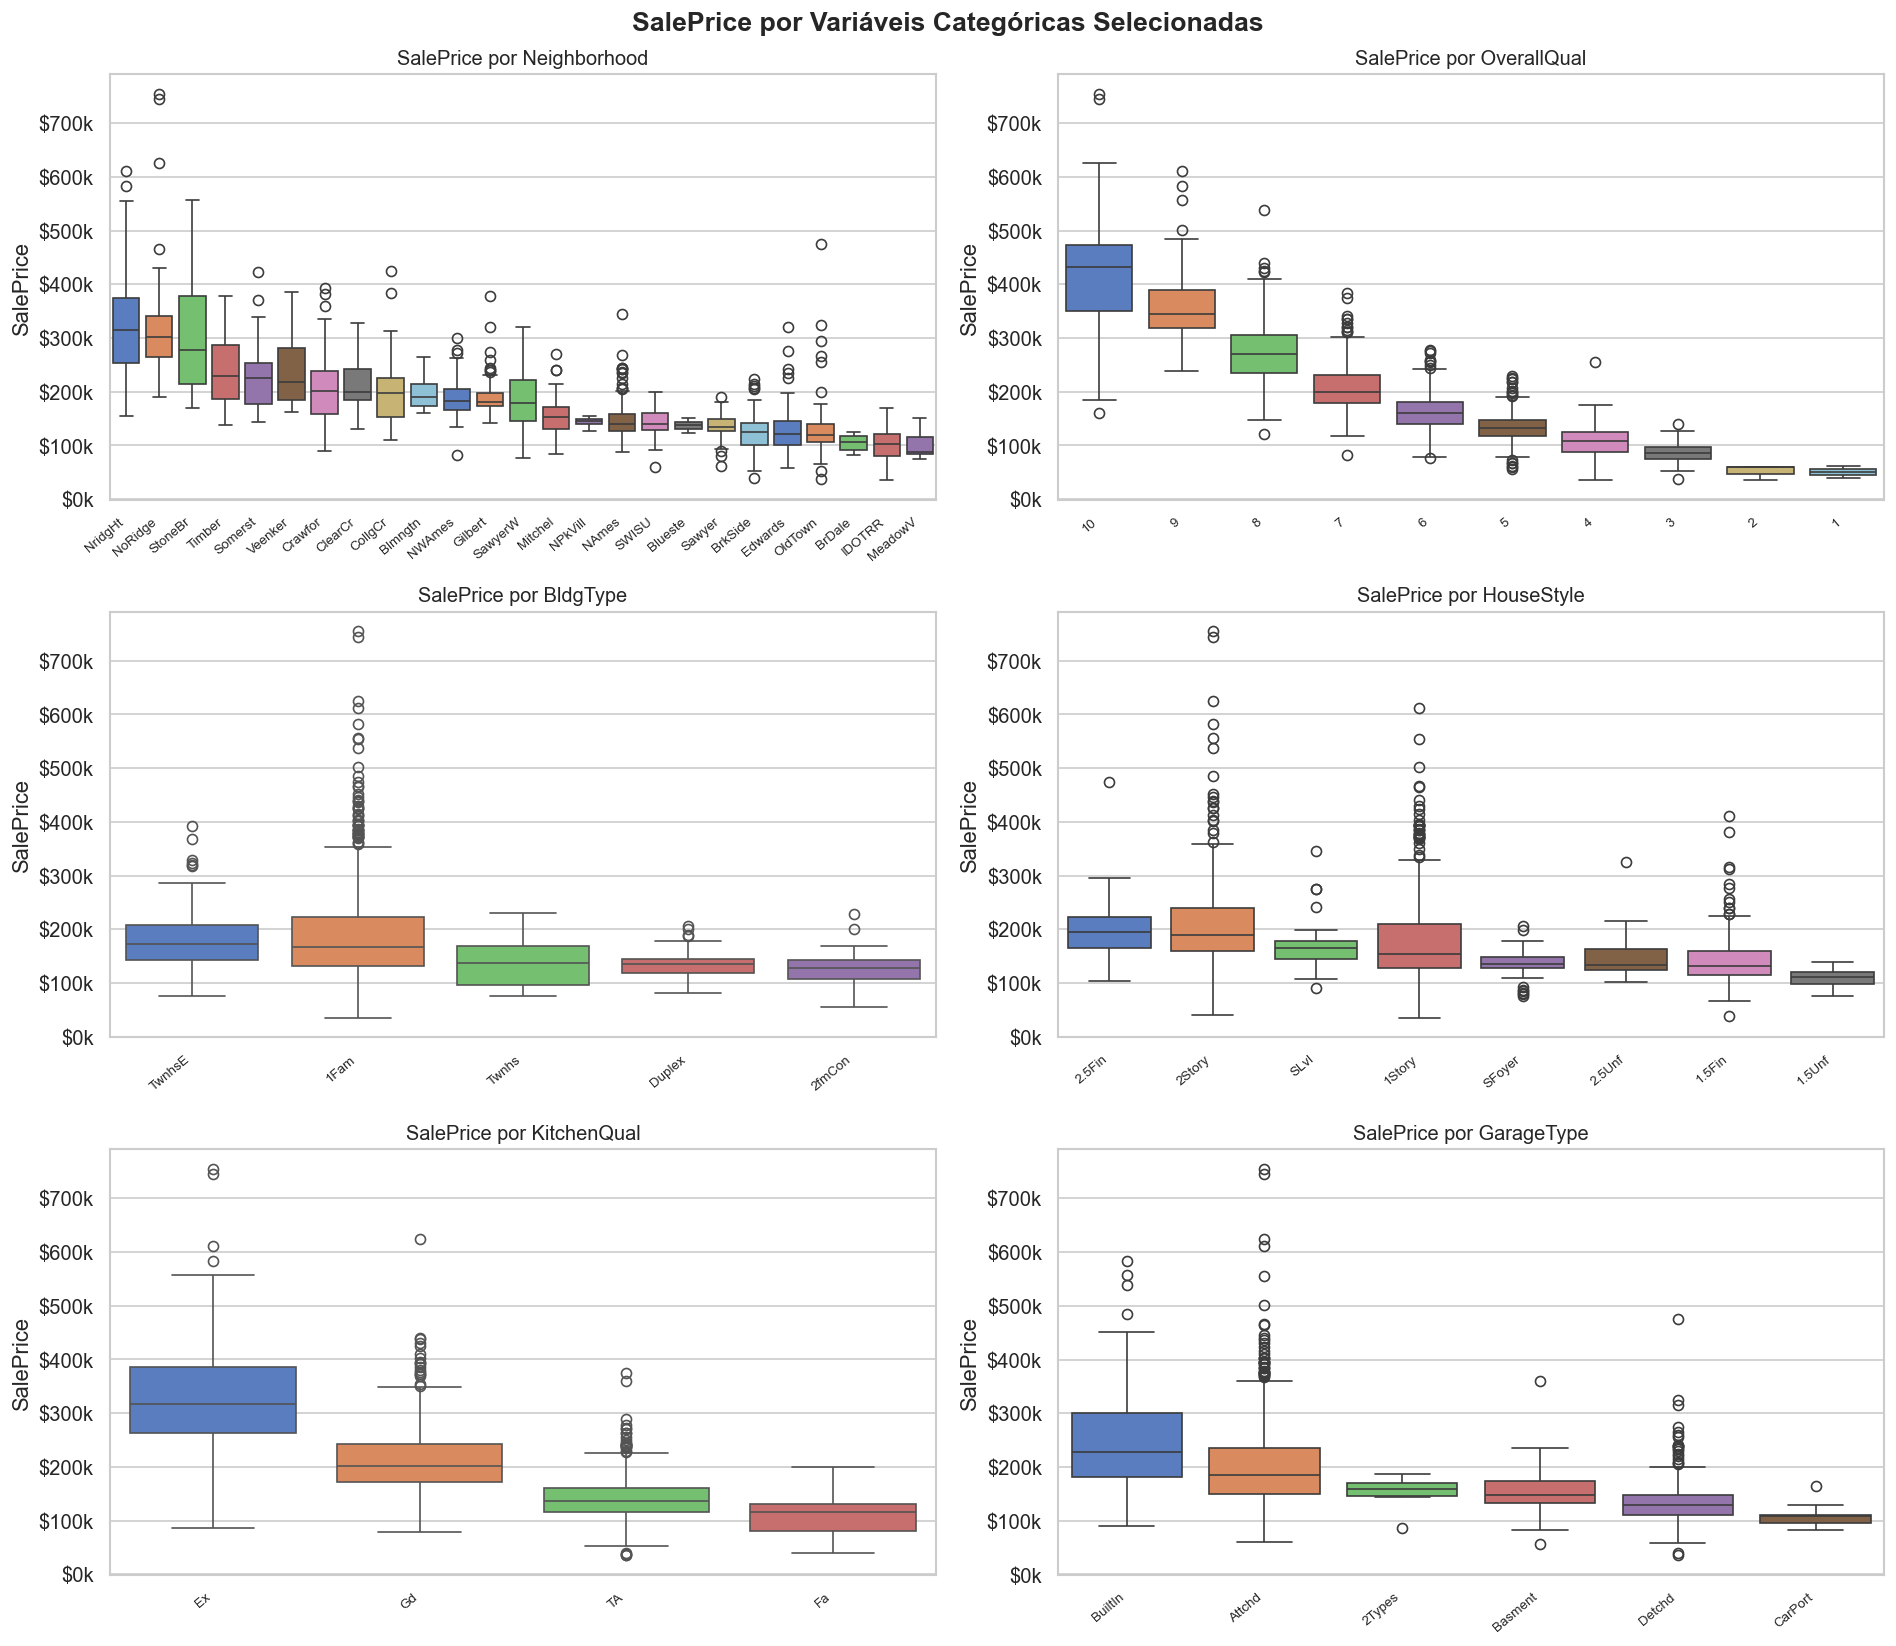

In [31]:
# ── Análise de variáveis categóricas ─────────────────────────────────────────
cat_cols = ['Neighborhood', 'OverallQual', 'BldgType', 'HouseStyle', 'KitchenQual', 'GarageType']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='SalePrice', order=order, ax=ax, palette='muted')
    ax.set_title(f'SalePrice por {col}', fontsize=12)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
plt.suptitle('SalePrice por Variáveis Categóricas Selecionadas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

In [32]:
# ── Cópia dos dados ───────────────────────────────────────────────────────────
df = train.copy()

# ── 1) Criação de novas features ──────────────────────────────────────────────
df['TotalSF']       = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath']     = (df['FullBath'] + 0.5 * df['HalfBath'] +
                       df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
df['HouseAge']      = df['YrSold'] - df['YearBuilt']
df['RemodAge']      = df['YrSold'] - df['YearRemodAdd']
df['IsRemodeled']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['HasGarage']     = (df['GarageArea'] > 0).astype(int)
df['HasPool']       = (df['PoolArea'] > 0).astype(int)
df['HasFireplace']  = (df['Fireplaces'] > 0).astype(int)
df['HasBsmt']       = (df['TotalBsmtSF'] > 0).astype(int)
df['PorchTotalSF']  = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                       df['3SsnPorch'] + df['ScreenPorch'])

print('✅ Novas features criadas:')
new_feats = ['TotalSF','TotalBath','HouseAge','RemodAge','IsRemodeled',
             'HasGarage','HasPool','HasFireplace','HasBsmt','PorchTotalSF']
df[new_feats + ['SalePrice']].describe().T

✅ Novas features criadas:


,count,mean,std,min,25%,50%,75%,max
TotalSF,1460.0,2567.048630,821.714421,334.0,2009.5,2474.0,3004.0,11752.0
TotalBath,1460.0,2.210616,0.785399,1.0,2.0,2.0,2.5,6.0
HouseAge,1460.0,36.547945,30.250152,0.0,8.0,35.0,54.0,136.0
RemodAge,1460.0,22.950000,20.640653,-1.0,4.0,14.0,41.0,60.0
IsRemodeled,1460.0,0.476712,0.499629,0.0,0.0,0.0,1.0,1.0
HasGarage,1460.0,0.944521,0.228992,0.0,1.0,1.0,1.0,1.0
HasPool,1460.0,0.004795,0.069100,0.0,0.0,0.0,0.0,1.0
HasFireplace,1460.0,0.527397,0.499420,0.0,0.0,1.0,1.0,1.0
HasBsmt,1460.0,0.974658,0.157217,0.0,1.0,1.0,1.0,1.0
PorchTotalSF,1460.0,87.084932,105.190364,0.0,0.0,48.0,136.0,1027.0


In [33]:
# ── 2) Tratamento de valores faltantes ────────────────────────────────────────

# Variáveis categóricas: NaN significa 'ausência' (ex: sem porão, sem garagem)
none_cols = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'MasVnrType','MSSubClass'
]
for c in none_cols:
    if c in df.columns:
        df[c].fillna('None', inplace=True)

# Variáveis numéricas com ausência estrutural (valor 0)
zero_cols = [
    'GarageYrBlt','GarageArea','GarageCars',
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath','BsmtHalfBath','MasVnrArea'
]
for c in zero_cols:
    if c in df.columns:
        df[c].fillna(0, inplace=True)

# Demais categóricas: moda
cat_remaining = df.select_dtypes(include='object').columns
for c in cat_remaining:
    df[c].fillna(df[c].mode()[0], inplace=True)

# Demais numéricas: mediana
num_remaining = df.select_dtypes(include=[np.number]).columns
for c in num_remaining:
    df[c].fillna(df[c].median(), inplace=True)

print(f'Valores faltantes restantes: {df.isnull().sum().sum()}')

Valores faltantes restantes: 0


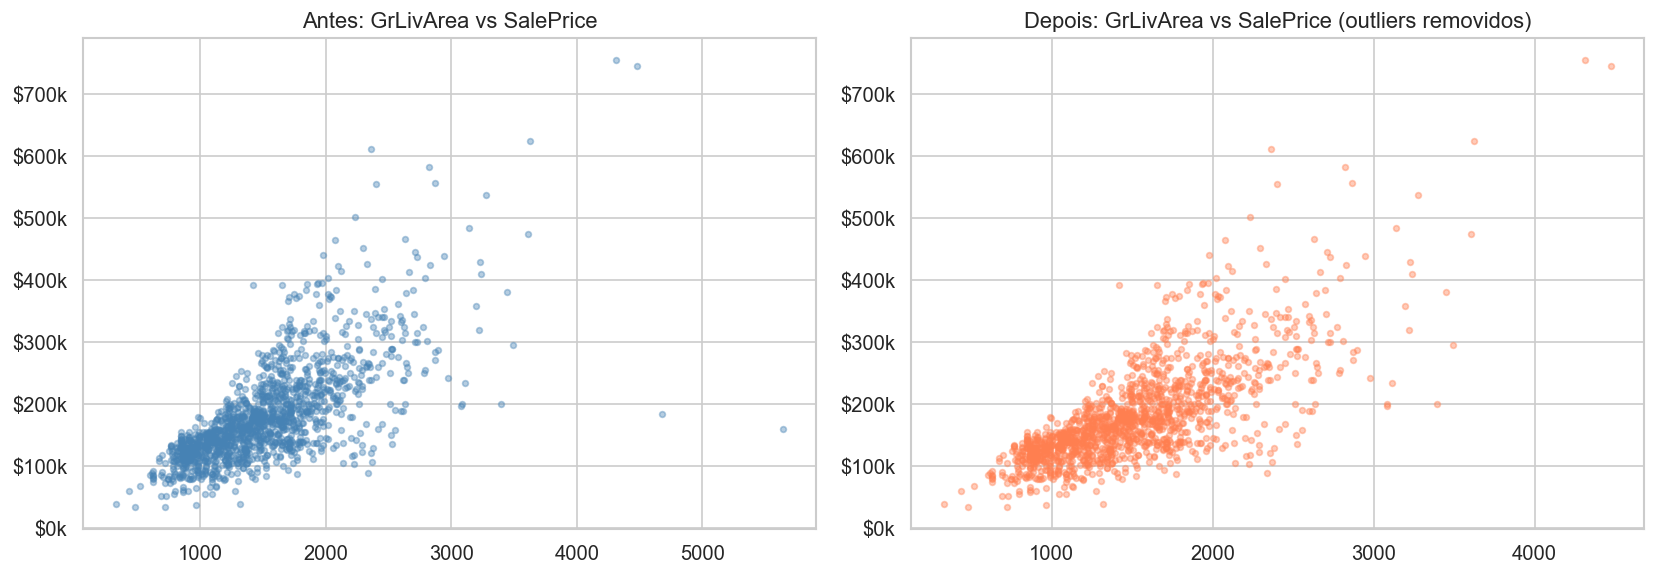

Dataset após remoção de outliers: (1458, 91)


In [34]:
# ── 3) Tratamento de Outliers (GrLivArea) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, s=12, color='steelblue')
axes[0].set_title('Antes: GrLivArea vs SalePrice')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Remover outliers óbvios
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]

axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, s=12, color='coral')
axes[1].set_title('Depois: GrLivArea vs SalePrice (outliers removidos)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()
print(f'Dataset após remoção de outliers: {df.shape}')

In [35]:
# ── 4) Log-transformação do target e de features assimétricas ─────────────────
df['SalePrice_log'] = np.log1p(df['SalePrice'])

# Corrigir skew de features numéricas
skew_cols = df[num_remaining].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skew_cols[skew_cols.abs() > 0.75].index.tolist()
# Remover colunas binárias e o target
skip = ['SalePrice','SalePrice_log','Id'] + [c for c in df.columns if df[c].nunique() <= 2]
high_skew = [c for c in high_skew if c not in skip]

for c in high_skew:
    if c in df.columns and (df[c] >= 0).all():
        df[c] = np.log1p(df[c])

print(f'Features com skew corrigido: {len(high_skew)}')

Features com skew corrigido: 23


In [36]:
# ── 5) Encoding de variáveis categóricas ──────────────────────────────────────
df_encoded = df.copy()

# Ordinal encoding para qualidade (Ex: Ex=5, Gd=4, TA=3, Fa=2, Po=1, None=0)
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
quality_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond',
                'HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond']
for c in quality_cols:
    if c in df_encoded.columns:
        df_encoded[c] = df_encoded[c].map(quality_map).fillna(0).astype(int)

# One-Hot Encoding para demais categóricas
cat_cols_enc = df_encoded.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols_enc, drop_first=True)

print(f'Shape após encoding: {df_encoded.shape}')
print(f'Tipos: {df_encoded.dtypes.value_counts().to_dict()}')

Shape após encoding: (1458, 243)
Tipos: {dtype('bool'): 185, dtype('int64'): 33, dtype('float64'): 25}


In [37]:
# ── 6) Preparar X e y ─────────────────────────────────────────────────────────
drop_cols = ['Id','SalePrice','SalePrice_log']
drop_cols = [c for c in drop_cols if c in df_encoded.columns]

X = df_encoded.drop(columns=drop_cols)
y_reg = df_encoded['SalePrice_log']        # Para regressão (log-transformado)
y_raw = df_encoded['SalePrice']            # Para visualizações
y_cls = (df_encoded['SalePrice'] >= df_encoded['SalePrice'].median()).astype(int)  # Para classificação

# Garantir que todas as colunas sejam numéricas
X = X.select_dtypes(include=[np.number])

# Normalização
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split treino/teste
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=SEED)
_, _, y_train_cls, y_test_cls = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=SEED)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Classes (0=baixo, 1=alto): {y_cls.value_counts().to_dict()}')

X_train: (1166, 55) | X_test: (292, 55)
Classes (0=baixo, 1=alto): {1: 731, 0: 727}


---
## 4. Aprendizagem Supervisionada — Regressão

In [38]:
# Remover NaN restantes do X
X_scaled = pd.DataFrame(X_scaled).fillna(0)

# Refazer o split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=SEED)
_, _, y_train_cls, y_test_cls = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=SEED)

print(f'NaN em X_train: {X_train.isnull().sum().sum()}')
print(f'NaN em X_test:  {X_test.isnull().sum().sum()}')

NaN em X_train: 0
NaN em X_test:  0


In [57]:
# ── Função auxiliar ────────────────────────────────────────────────────────────
def eval_regressor(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    return {'Modelo': name, 'RMSE (log)': round(rmse,4), 'MAE (log)': round(mae,4),
            'R²': round(r2,4), 'R² CV-5': round(cv,4)}

reg_results = []
models_reg = {
    'Regressão Linear':   LinearRegression(),
    'Ridge':              Ridge(alpha=10),
    'Lasso':              Lasso(alpha=0.001),
    'Random Forest':      RandomForestRegressor(n_estimators=200, random_state=SEED),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED),
    'XGBoost':            XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED, verbosity=0)
}

for name, model in models_reg.items():
    res = eval_regressor(name, model, X_train, X_test, y_train_reg, y_test_reg)
    reg_results.append(res)
    print(f'[{name}] RMSE={res["RMSE (log)"]:.4f}  R²={res["R²"]:.4f}  R²CV={res["R² CV-5"]:.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False)
print('\n=== RANKING DOS MODELOS DE REGRESSÃO ===')
reg_df

[Regressão Linear] RMSE=0.1250  R²=0.9073  R²CV=0.8978
[Ridge] RMSE=0.1252  R²=0.9070  R²CV=0.9003
[Lasso] RMSE=0.1267  R²=0.9048  R²CV=0.9006
[Random Forest] RMSE=0.1503  R²=0.8661  R²CV=0.8767
[Gradient Boosting] RMSE=0.1276  R²=0.9035  R²CV=0.8916
[XGBoost] RMSE=0.1457  R²=0.8740  R²CV=0.8805

=== RANKING DOS MODELOS DE REGRESSÃO ===


,Modelo,RMSE (log),MAE (log),R²,R² CV-5
0,Regressão Linear,0.1250,0.0879,0.9073,0.8978
1,Ridge,0.1252,0.0881,0.9070,0.9003
2,Lasso,0.1267,0.0889,0.9048,0.9006
4,Gradient Boosting,0.1276,0.0874,0.9035,0.8916
5,XGBoost,0.1457,0.0943,0.8740,0.8805
3,Random Forest,0.1503,0.0986,0.8661,0.8767


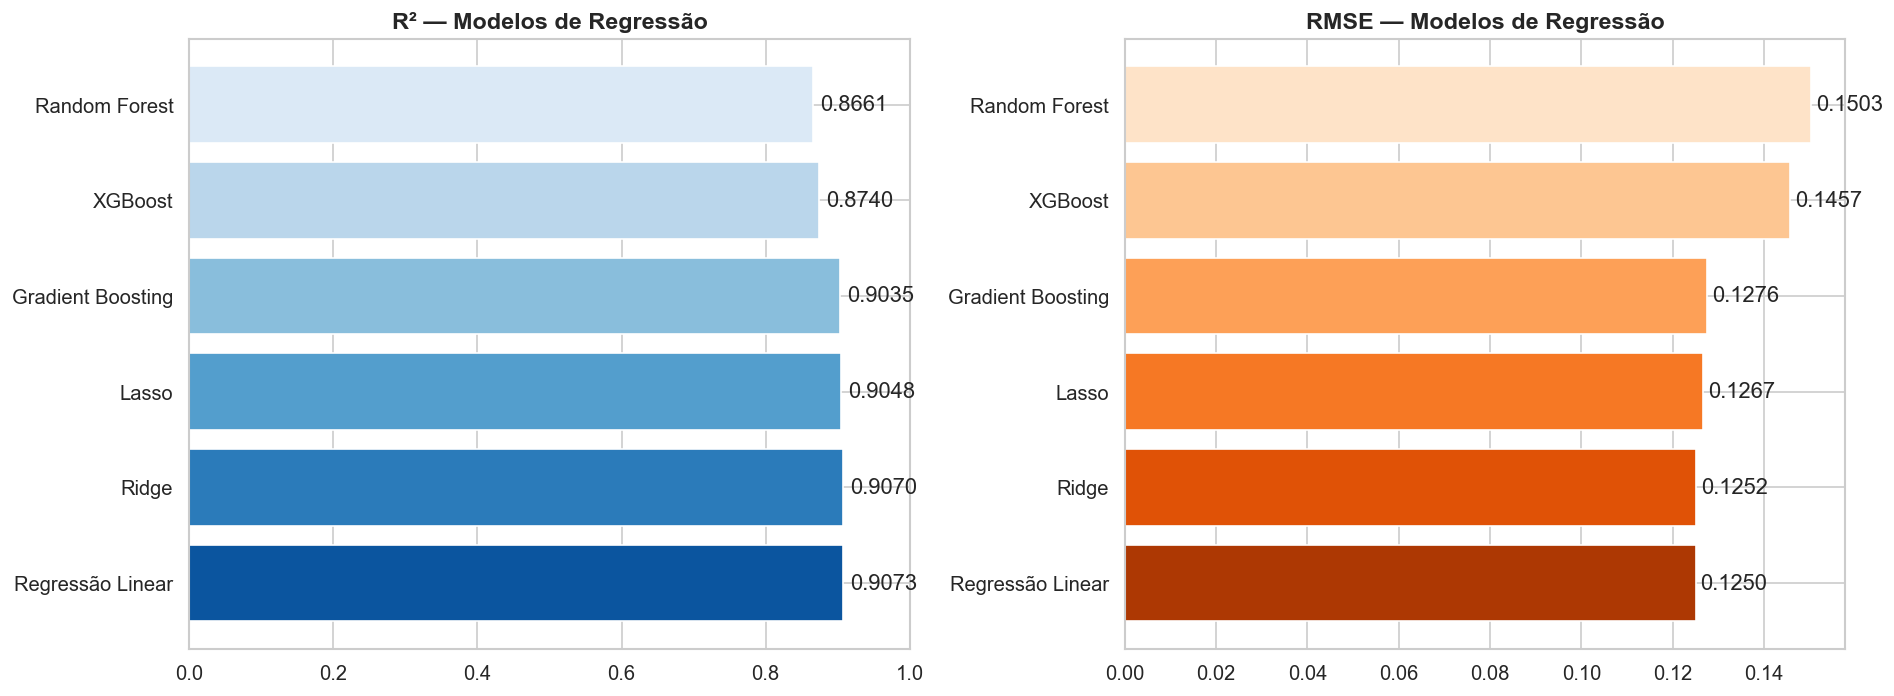

In [40]:
# ── Visualização dos resultados de regressão ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R²
axes[0].barh(reg_df['Modelo'], reg_df['R²'], color=sns.color_palette('Blues_r', len(reg_df)))
axes[0].set_title('R² — Modelos de Regressão', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)
for i, v in enumerate(reg_df['R²']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# RMSE
axes[1].barh(reg_df['Modelo'], reg_df['RMSE (log)'], color=sns.color_palette('Oranges_r', len(reg_df)))
axes[1].set_title('RMSE — Modelos de Regressão', fontsize=14, fontweight='bold')
for i, v in enumerate(reg_df['RMSE (log)']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

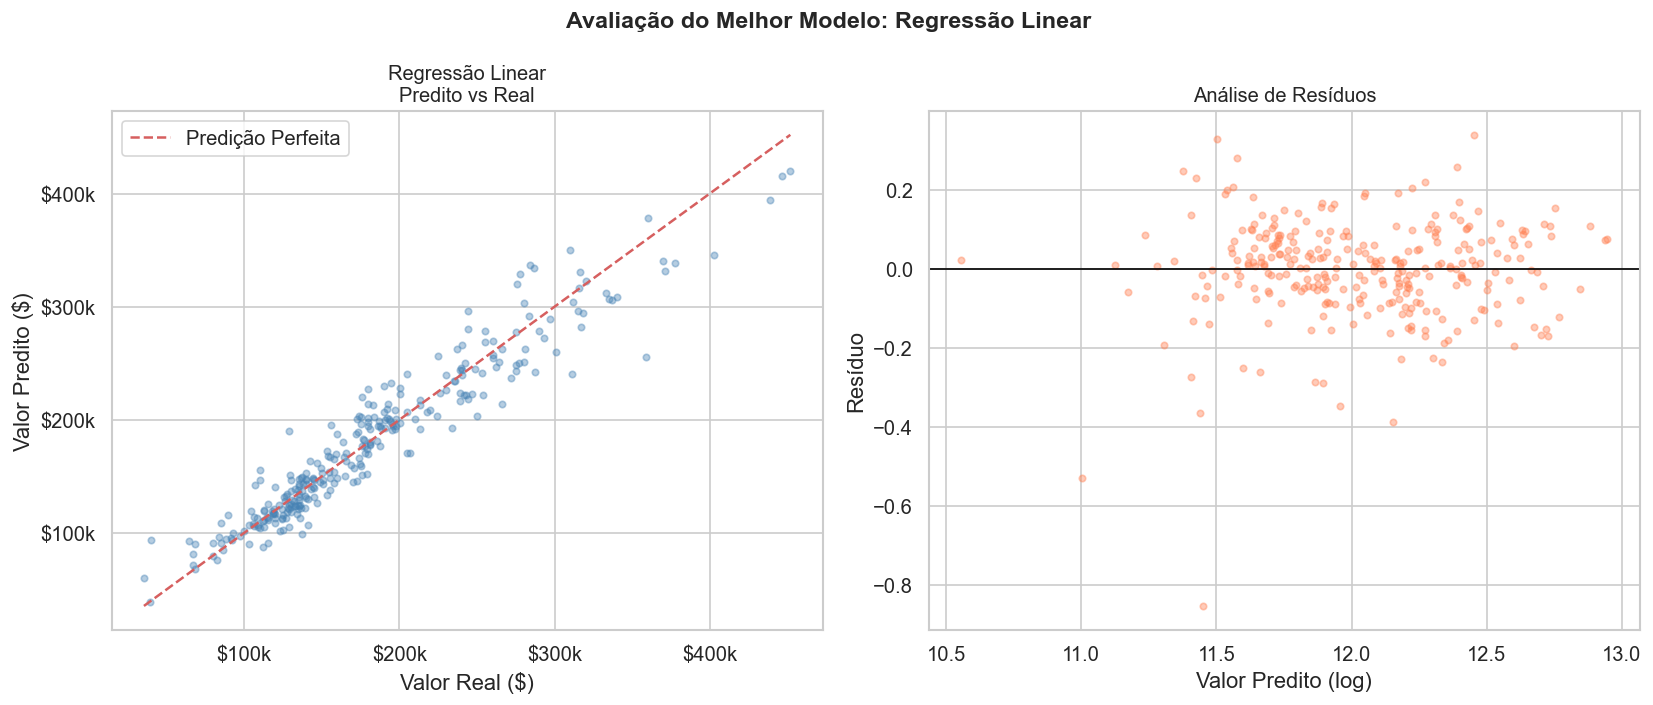

In [58]:
# ── Predicted vs Actual — Melhor modelo ──────────────────────────────────────
best_reg_name = reg_df.iloc[0]['Modelo']
best_reg = models_reg[best_reg_name]
best_reg.fit(X_train, y_train_reg)
y_pred_best = best_reg.predict(X_test)

# De-log para visualização em $
y_true_dollar = np.expm1(y_test_reg)
y_pred_dollar = np.expm1(y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter predicted vs actual
axes[0].scatter(y_true_dollar, y_pred_dollar, alpha=0.4, s=15, color='steelblue')
lims = [min(y_true_dollar.min(), y_pred_dollar.min()), max(y_true_dollar.max(), y_pred_dollar.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predição Perfeita')
axes[0].set_xlabel('Valor Real ($)')
axes[0].set_ylabel('Valor Predito ($)')
axes[0].set_title(f'{best_reg_name}\nPredito vs Real', fontsize=12)
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Resíduos
residuals = y_test_reg.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Valor Predito (log)')
axes[1].set_ylabel('Resíduo')
axes[1].set_title('Análise de Resíduos', fontsize=12)

plt.suptitle(f'Avaliação do Melhor Modelo: {best_reg_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

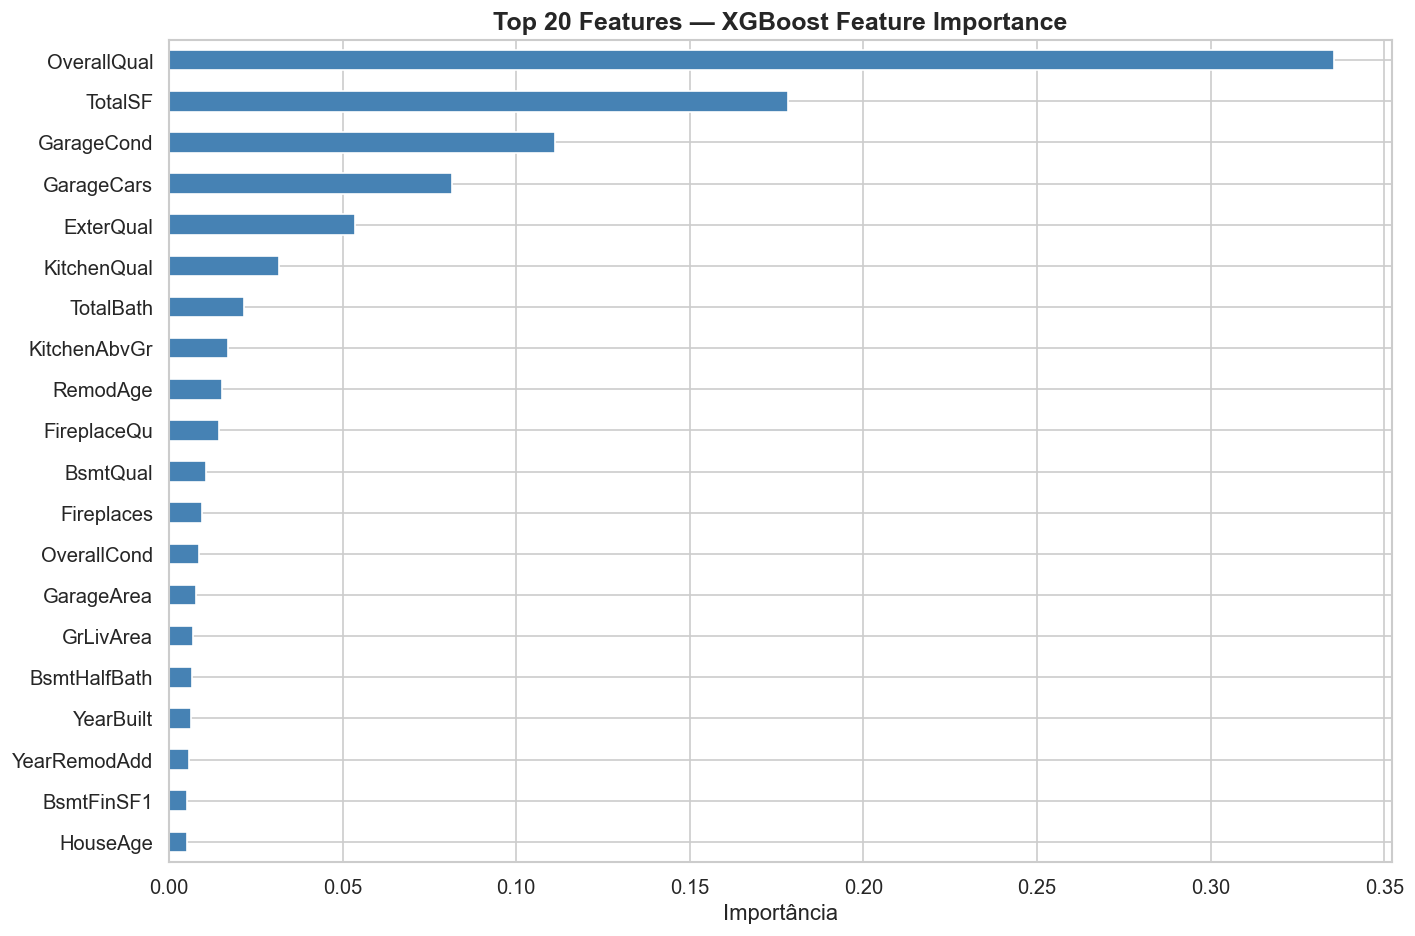

In [42]:
# ── Feature Importance — XGBoost ──────────────────────────────────────────────
xgb_model = models_reg['XGBoost']
xgb_model.fit(X_train, y_train_reg)

feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features — XGBoost Feature Importance', fontsize=15, fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()

---
## 5. Aprendizagem Supervisionada — Classificação

Mediana do SalePrice: $163,000
Distribuição das classes: {1: 731, 0: 727}


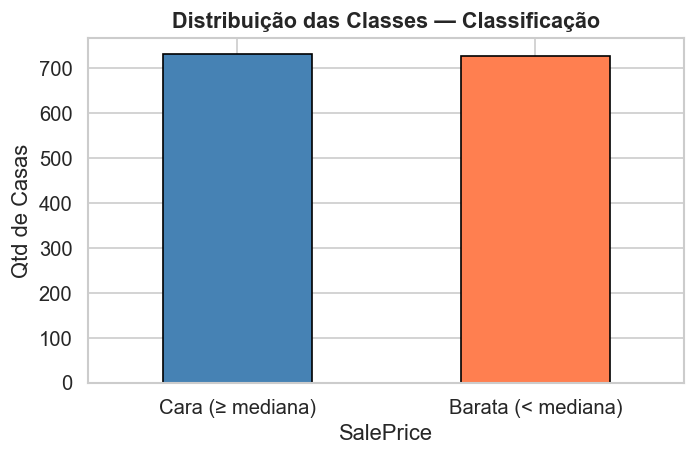

In [43]:
# ── Objetivo: prever se uma casa é 'cara' (acima da mediana) ou 'barata' ───────
median_price = train['SalePrice'].median()
print(f'Mediana do SalePrice: ${median_price:,.0f}')
print(f'Distribuição das classes: {y_cls.value_counts().to_dict()}')

fig, ax = plt.subplots(figsize=(6, 4))
y_cls.value_counts().rename({0: 'Barata (< mediana)', 1: 'Cara (≥ mediana)'}).plot(
    kind='bar', ax=ax, color=['steelblue','coral'], edgecolor='black')
ax.set_title('Distribuição das Classes — Classificação', fontsize=13, fontweight='bold')
ax.set_ylabel('Qtd de Casas')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [44]:
# ── Treinamento dos classificadores ──────────────────────────────────────────
def eval_classifier(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    try:
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
    except Exception:
        auc = np.nan
    cv = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    return {'Modelo': name, 'Acurácia': round(acc,4), 'AUC-ROC': round(auc,4) if not np.isnan(auc) else '-', 'Acc CV-5': round(cv,4)}

cls_results = []
models_cls = {
    'Regressão Logística': LogisticRegression(max_iter=500, random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=9),
    'Árvore de Decisão':   DecisionTreeClassifier(max_depth=8, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=SEED, verbosity=0, use_label_encoder=False, eval_metric='logloss')
}

for name, model in models_cls.items():
    res = eval_classifier(name, model, X_train, X_test, y_train_cls, y_test_cls)
    cls_results.append(res)
    print(f'[{name}] Acc={res["Acurácia"]:.4f}  AUC={res["AUC-ROC"]}  AccCV={res["Acc CV-5"]:.4f}')

cls_df = pd.DataFrame(cls_results).sort_values('Acurácia', ascending=False)
print('\n=== RANKING DOS CLASSIFICADORES ===')
cls_df

[Regressão Logística] Acc=0.9486  AUC=0.9865  AccCV=0.9142
[KNN] Acc=0.9212  AUC=0.9735  AccCV=0.8774
[Árvore de Decisão] Acc=0.9110  AUC=0.9193  AccCV=0.8774
[Random Forest] Acc=0.9349  AUC=0.9835  AccCV=0.9125
[XGBoost] Acc=0.9452  AUC=0.9837  AccCV=0.9065

=== RANKING DOS CLASSIFICADORES ===


,Modelo,Acurácia,AUC-ROC,Acc CV-5
0,Regressão Logística,0.9486,0.9865,0.9142
4,XGBoost,0.9452,0.9837,0.9065
3,Random Forest,0.9349,0.9835,0.9125
1,KNN,0.9212,0.9735,0.8774
2,Árvore de Decisão,0.9110,0.9193,0.8774


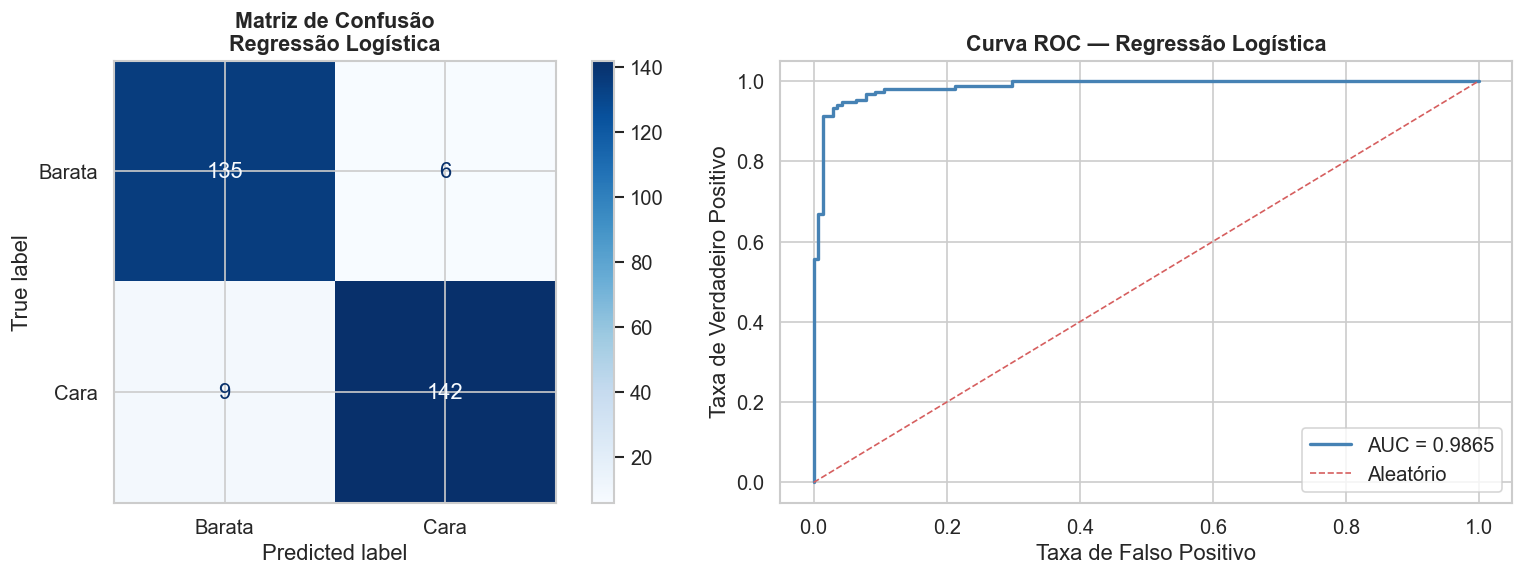


Relatório de Classificação:
              precision    recall  f1-score   support

      Barata       0.94      0.96      0.95       141
        Cara       0.96      0.94      0.95       151

    accuracy                           0.95       292
   macro avg       0.95      0.95      0.95       292
weighted avg       0.95      0.95      0.95       292



In [45]:
# ── Matriz de Confusão — melhor classificador ─────────────────────────────────
best_cls_name = cls_df.iloc[0]['Modelo']
best_cls = models_cls[best_cls_name]
best_cls.fit(X_train, y_train_cls)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
disp = ConfusionMatrixDisplay.from_estimator(
    best_cls, X_test, y_test_cls,
    display_labels=['Barata','Cara'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Matriz de Confusão\n{best_cls_name}', fontsize=13, fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_cls, best_cls.predict_proba(X_test)[:,1])
auc_val = roc_auc_score(y_test_cls, best_cls.predict_proba(X_test)[:,1])
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1],[0,1],'r--', linewidth=1, label='Aleatório')
axes[1].set_xlabel('Taxa de Falso Positivo')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
axes[1].set_title(f'Curva ROC — {best_cls_name}', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nRelatório de Classificação:')
print(classification_report(y_test_cls, best_cls.predict(X_test), target_names=['Barata','Cara']))

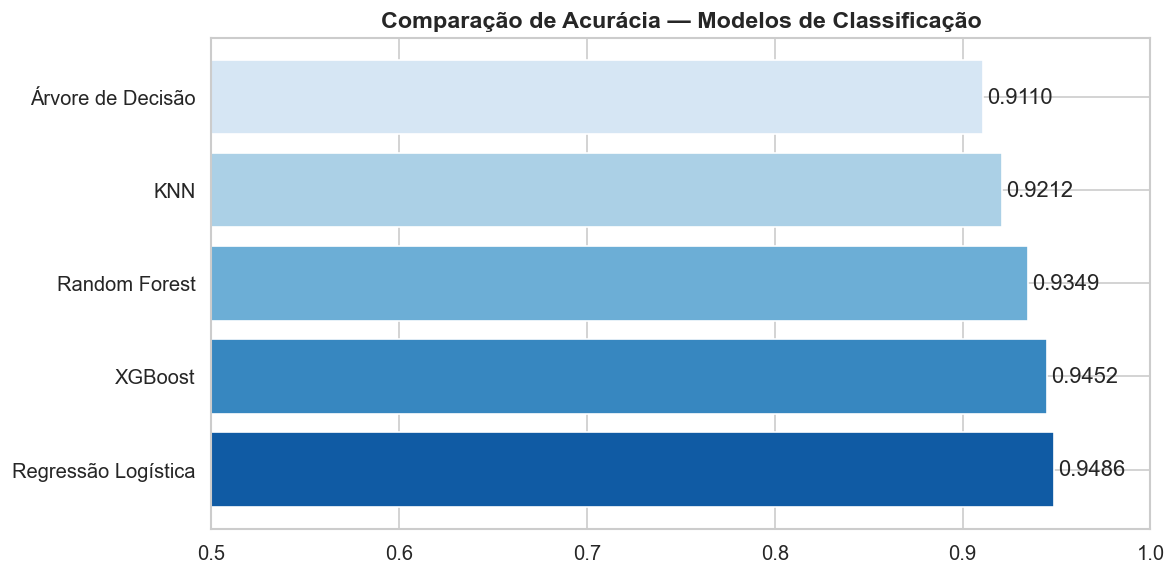

In [46]:
# ── Comparação de acurácia entre todos os modelos ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cls_df['Modelo'], cls_df['Acurácia'], color=sns.color_palette('Blues_r', len(cls_df)))
ax.set_xlim(0.5, 1)
ax.set_title('Comparação de Acurácia — Modelos de Classificação', fontsize=14, fontweight='bold')
for i, v in enumerate(cls_df['Acurácia']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

---
## 6. Aprendizagem Não Supervisionada

### 6.1 Redução de Dimensionalidade (PCA)

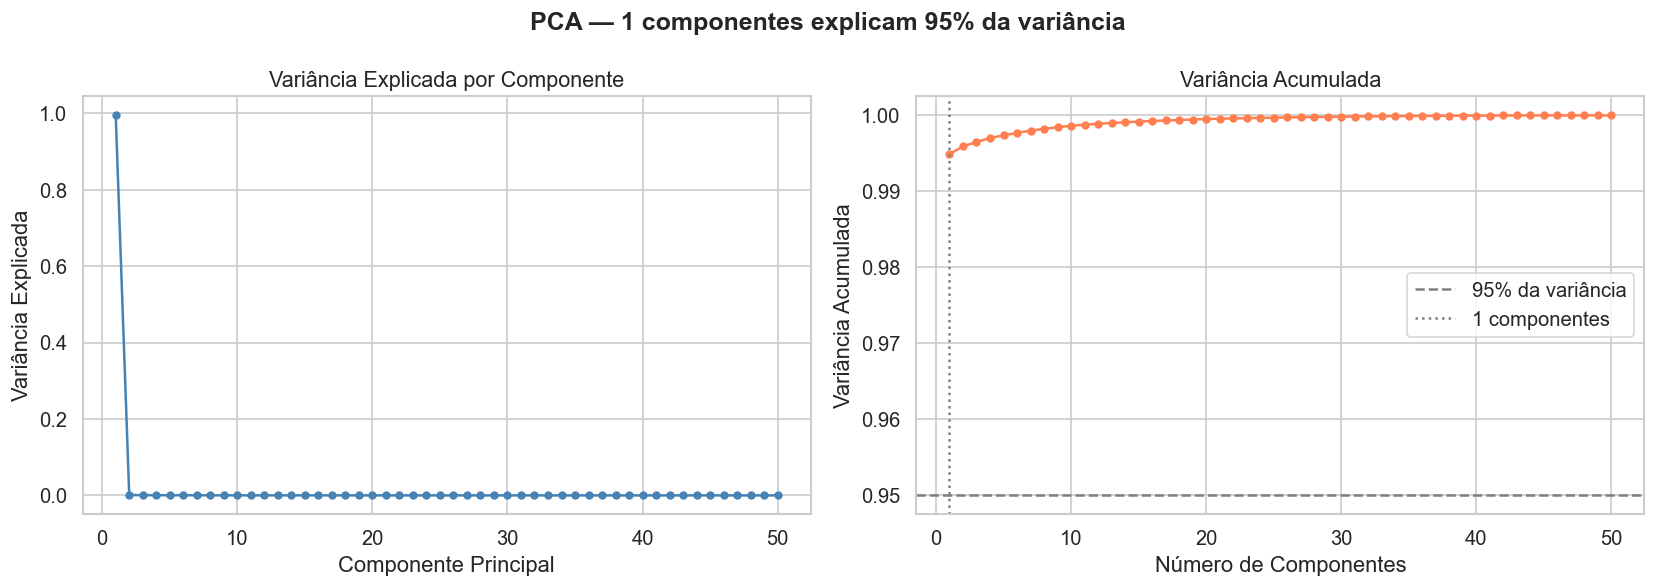


✅ Componentes para 95% da variância: 1 (de 55 features originais)


In [47]:
# ── PCA ────────────────────────────────────────────────────────────────────────
pca = PCA(n_components=50, random_state=SEED)
pca.fit(X_scaled)

# Variância acumulada
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 51), pca.explained_variance_ratio_, 'o-', color='steelblue', markersize=4)
axes[0].set_title('Variância Explicada por Componente', fontsize=13)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')

axes[1].plot(range(1, 51), cum_var, 'o-', color='coral', markersize=4)
axes[1].axhline(0.95, color='gray', linestyle='--', label='95% da variância')
axes[1].axvline(n_95, color='gray', linestyle=':', label=f'{n_95} componentes')
axes[1].set_title('Variância Acumulada', fontsize=13)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada')
axes[1].legend()

plt.suptitle(f'PCA — {n_95} componentes explicam 95% da variância', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\n✅ Componentes para 95% da variância: {n_95} (de {X_scaled.shape[1]} features originais)')

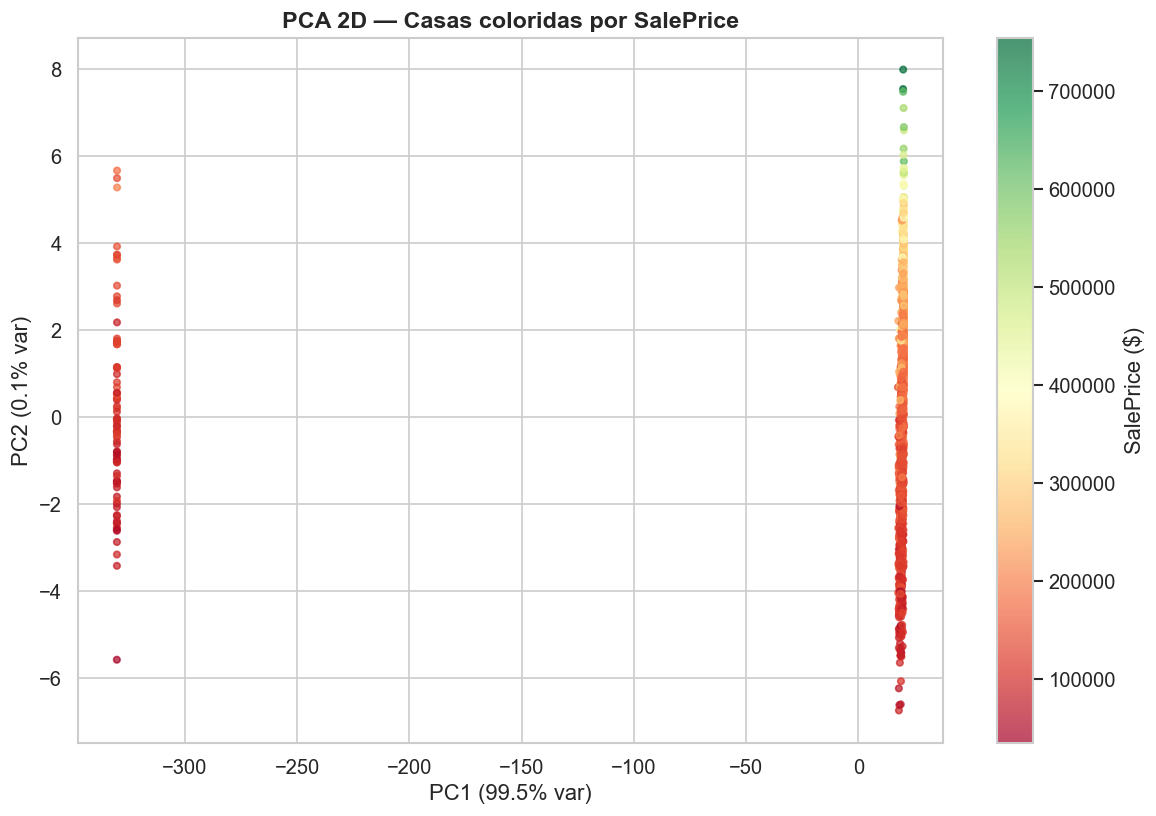

In [48]:
# ── Visualização 2D com PCA ───────────────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2d = pca_2d.fit_transform(X_scaled)

# Colorir pelo preço
price_vals = df_encoded['SalePrice'].values[:len(X_scaled)]

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca2d[:,0], X_pca2d[:,1], c=price_vals, cmap='RdYlGn', s=15, alpha=0.7)
plt.colorbar(sc, ax=ax, label='SalePrice ($)')
ax.set_title('PCA 2D — Casas coloridas por SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.show()

### 6.2 Clusterização (K-Means)

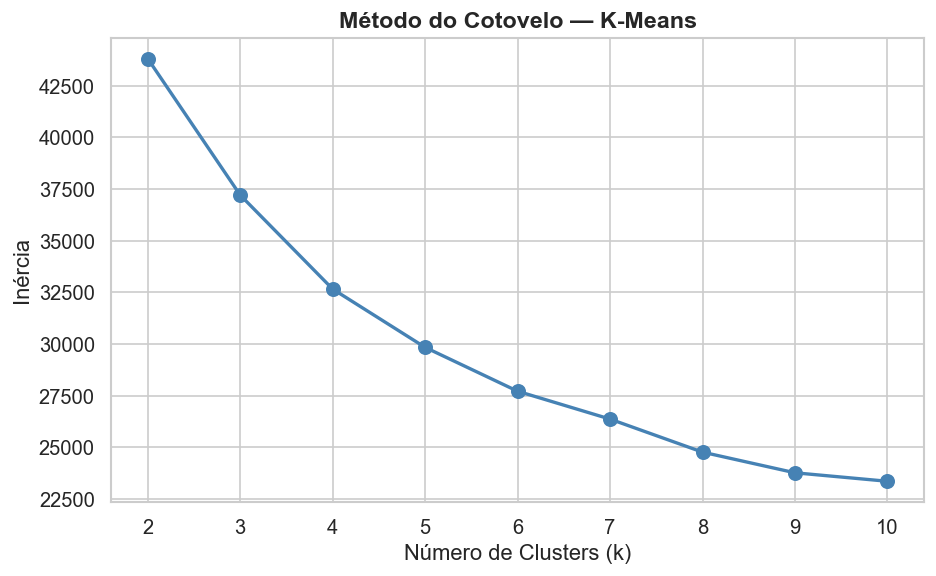

In [49]:
# ── Método do Cotovelo ────────────────────────────────────────────────────────
pca_cluster = PCA(n_components=20, random_state=SEED)
X_pca = pca_cluster.fit_transform(X_scaled)

inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (k)')
ax.set_ylabel('Inércia')
ax.set_title('Método do Cotovelo — K-Means', fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

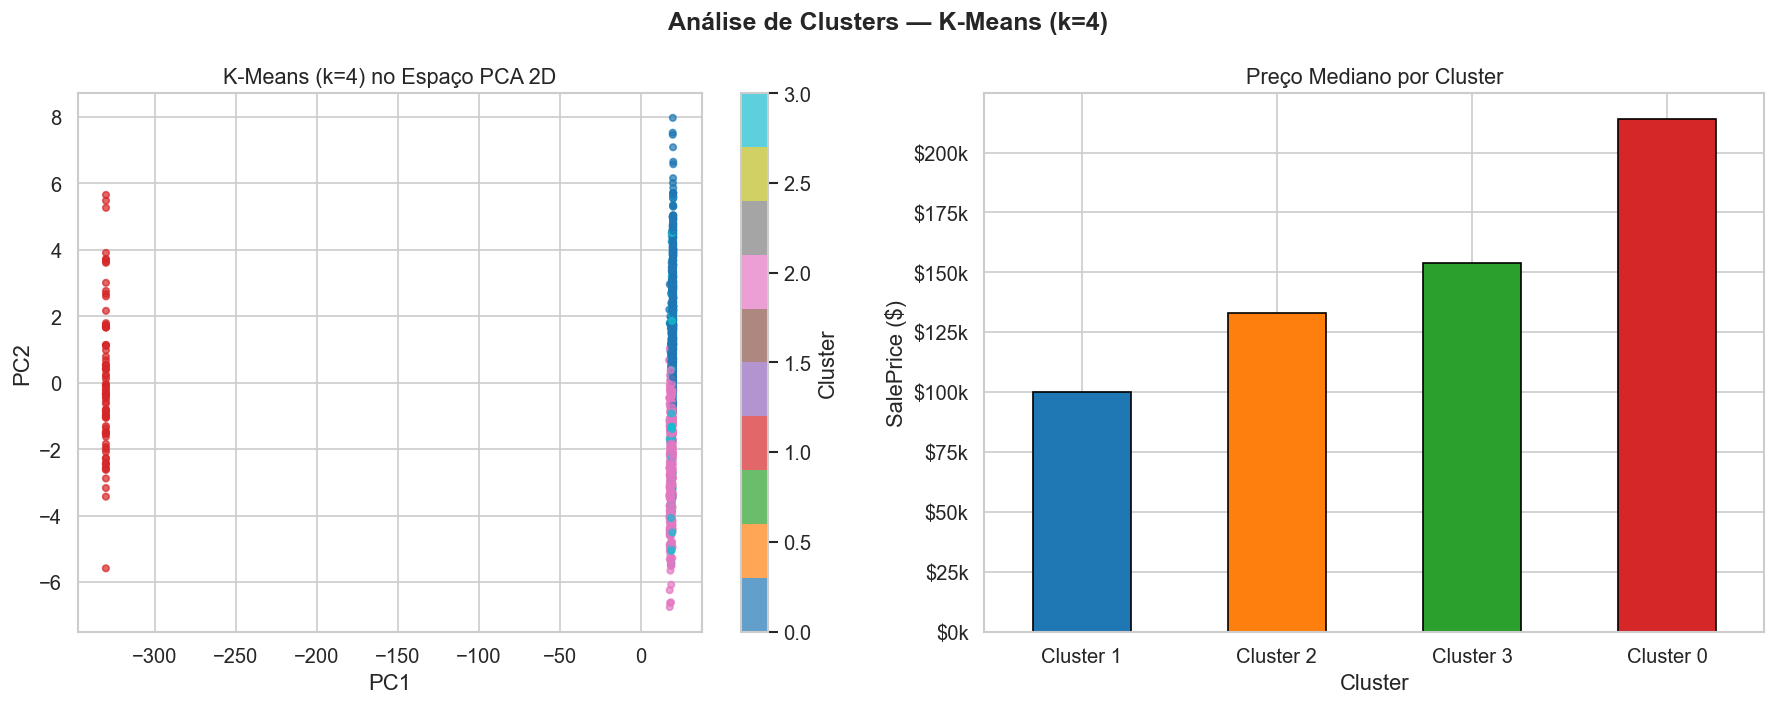


Estatísticas de SalePrice por Cluster:


,mean,median,count
Cluster,,,
0,235080.0,214000.0,649
1,103317.0,100000.0,81
2,133186.0,133000.0,566
3,169637.0,154000.0,162


In [50]:
# ── K-Means com k=4 ───────────────────────────────────────────────────────────
K_BEST = 4
kmeans = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Visualização no espaço PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter = axes[0].scatter(X_pca2d[:,0], X_pca2d[:,1],
                          c=clusters, cmap='tab10', s=15, alpha=0.7)
axes[0].set_title(f'K-Means (k={K_BEST}) no Espaço PCA 2D', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Preço médio por cluster
price_by_cluster = df_encoded['SalePrice'].values[:len(clusters)]
cluster_prices = pd.DataFrame({'Cluster': clusters, 'SalePrice': price_by_cluster})
cluster_prices.groupby('Cluster')['SalePrice'].median().sort_values().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('tab10', K_BEST), edgecolor='black'
)
axes[1].set_title('Preço Mediano por Cluster', fontsize=13)
axes[1].set_ylabel('SalePrice ($)')
axes[1].set_xlabel('Cluster')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_xticklabels([f'Cluster {c}' for c in cluster_prices.groupby('Cluster')['SalePrice'].median().sort_values().index], rotation=0)

plt.suptitle(f'Análise de Clusters — K-Means (k={K_BEST})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nEstatísticas de SalePrice por Cluster:')
cluster_prices.groupby('Cluster')['SalePrice'].agg(['mean','median','count']).round(0)

### 6.3 Análise de Outliers (Local Outlier Factor)

Outliers detectados: 73 (5.0%)


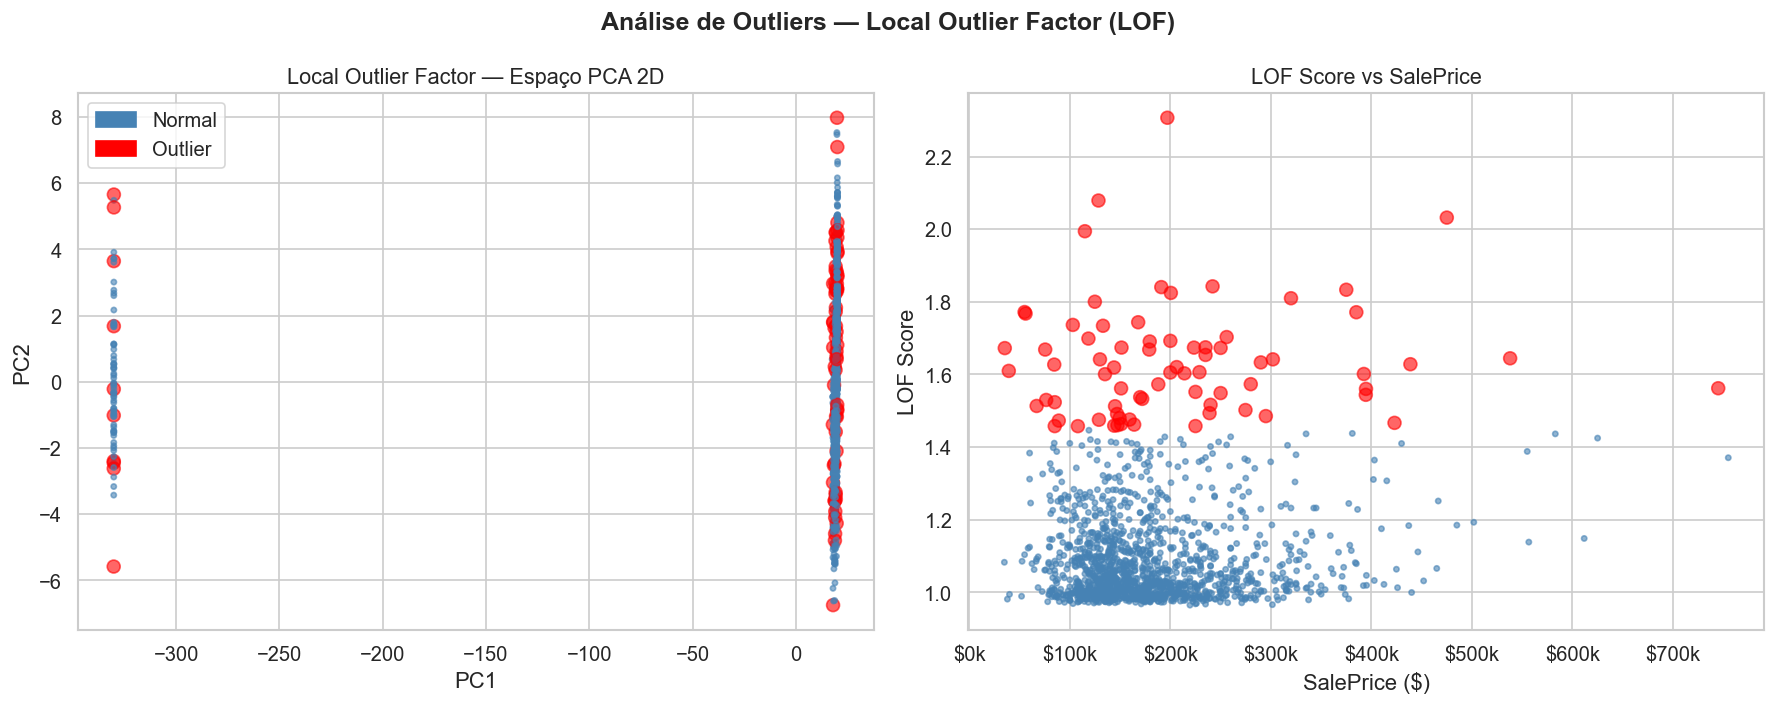

In [51]:
# ── LOF ────────────────────────────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_pca)  # -1 = outlier, 1 = normal
lof_scores = -lof.negative_outlier_factor_

n_outliers = (lof_labels == -1).sum()
print(f'Outliers detectados: {n_outliers} ({n_outliers/len(lof_labels)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualização no espaço PCA
colors = np.where(lof_labels == -1, 'red', 'steelblue')
axes[0].scatter(X_pca2d[:,0], X_pca2d[:,1], c=colors, s=np.where(lof_labels==-1, 60, 10), alpha=0.6)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='steelblue', label='Normal'),
    Patch(color='red', label='Outlier')
])
axes[0].set_title('Local Outlier Factor — Espaço PCA 2D', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# LOF Score vs SalePrice
price_lof = df_encoded['SalePrice'].values[:len(lof_scores)]
sc2 = axes[1].scatter(price_lof, lof_scores,
                      c=np.where(lof_labels==-1, 'red', 'steelblue'),
                      s=np.where(lof_labels==-1, 60, 10), alpha=0.6)
axes[1].set_xlabel('SalePrice ($)')
axes[1].set_ylabel('LOF Score')
axes[1].set_title('LOF Score vs SalePrice', fontsize=13)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Análise de Outliers — Local Outlier Factor (LOF)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Análise de Associação (Apriori)

In [52]:
# ── Preparação para Apriori ───────────────────────────────────────────────────
# Criar categorias discretas para features numéricas
ap_df = df[['OverallQual','TotalBath','GarageCars','HasFireplace','HasPool',
            'HasGarage','IsRemodeled','BedroomAbvGr']].copy()

# Discretizar
ap_df['OverallQual_cat'] = pd.cut(df['OverallQual'], bins=[0,4,6,10], labels=['Baixa','Média','Alta'])
ap_df['TotalBath_cat']   = pd.cut(df['TotalBath'],   bins=[0,1.5,2.5,10], labels=['1Bath','2Bath','3+Bath'])
ap_df['Bedrooms_cat']    = pd.cut(df['BedroomAbvGr'],bins=[0,2,3,10], labels=['1-2Qtos','3Qtos','4+Qtos'])
ap_df['Garage_cat']      = df['GarageCars'].apply(lambda x: f'Garage{int(x)}car')
ap_df['Price_cat']       = pd.cut(df['SalePrice'],
                                   bins=[0, 130000, 180000, 250000, 1e9],
                                   labels=['Barata','Media','Cara','Luxo'])

# Criar itens
use_cols = ['OverallQual_cat','TotalBath_cat','Bedrooms_cat','Garage_cat','Price_cat',
            'HasFireplace','HasPool','IsRemodeled']
transactions = []
for _, row in ap_df.iterrows():
    items = []
    for col in use_cols:
        val = row[col]
        if pd.notna(val):
            if col in ['HasFireplace','HasPool','IsRemodeled']:
                if val == 1:
                    items.append(col)
            else:
                items.append(str(val))
    transactions.append(items)

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

# Apriori
frequent_itemsets = apriori(df_te, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.2)
rules = rules.sort_values('lift', ascending=False)

print(f'Regras de associação encontradas: {len(rules)}')
print('\n=== TOP 10 REGRAS (por lift) ===')
rules[['antecedents','consequents','support','confidence','lift']].head(10)

Regras de associação encontradas: 262

=== TOP 10 REGRAS (por lift) ===


,antecedents,consequents,support,confidence,lift
159,(Luxo),"(HasFireplace, Alta)",0.137174,0.921659,3.342733
158,"(HasFireplace, Alta)",(Luxo),0.137174,0.497512,3.342733
148,"(HasFireplace, Alta)",(Garage3car),0.102881,0.373134,3.022388
149,(Garage3car),"(HasFireplace, Alta)",0.102881,0.833333,3.022388
151,(Alta),"(Garage3car, HasFireplace)",0.102881,0.274725,2.600970
146,"(Garage3car, HasFireplace)",(Alta),0.102881,0.974026,2.600970
23,(Alta),(Luxo),0.144033,0.384615,2.584190
22,(Luxo),(Alta),0.144033,0.967742,2.584190
156,"(Luxo, HasFireplace)",(Alta),0.137174,0.966184,2.580029
161,(Alta),"(Luxo, HasFireplace)",0.137174,0.366300,2.580029


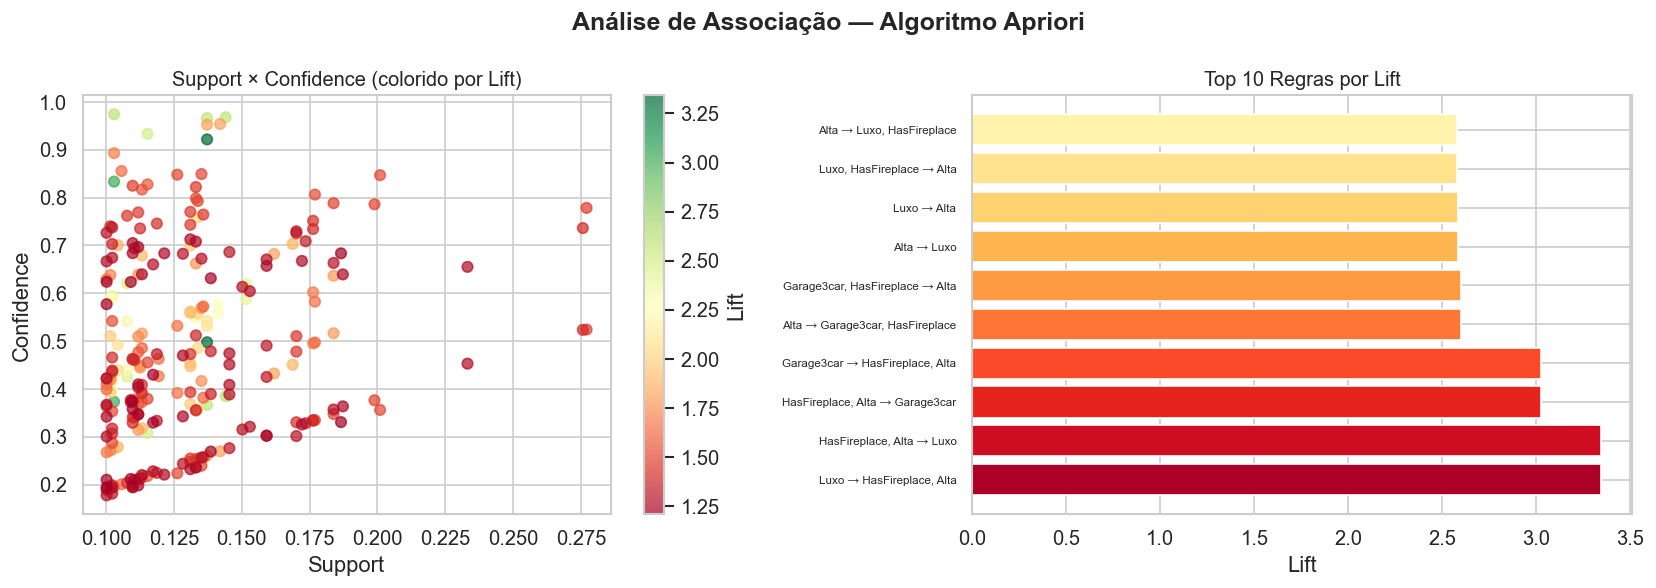

In [53]:
# ── Visualização das regras de associação ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Support vs Confidence
sc = axes[0].scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='RdYlGn', s=40, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support × Confidence (colorido por Lift)', fontsize=12)

# Top 10 lifts
top_rules = rules.head(10).copy()
top_rules['label'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' → ' + \
                     top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
axes[1].barh(range(10), top_rules['lift'].values, color=sns.color_palette('YlOrRd_r', 10))
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top_rules['label'].values, fontsize=7)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Regras por Lift', fontsize=12)

plt.suptitle('Análise de Associação — Algoritmo Apriori', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Métricas e Comparação dos Modelos

In [54]:
# ── Tabela final — Regressão ──────────────────────────────────────────────────
print('=== COMPARAÇÃO FINAL — REGRESSÃO ===')
reg_final = reg_df.set_index('Modelo')
reg_final.style \
    .background_gradient(cmap='Greens', subset=['R²','R² CV-5']) \
    .background_gradient(cmap='Reds_r', subset=['RMSE (log)','MAE (log)'])

=== COMPARAÇÃO FINAL — REGRESSÃO ===


,RMSE (log),MAE (log),R²,R² CV-5
Modelo,,,,
Regressão Linear,0.125000,0.087900,0.907300,0.897800
Ridge,0.125200,0.088100,0.907000,0.900300
Lasso,0.126700,0.088900,0.904800,0.900600
Gradient Boosting,0.127600,0.087400,0.903500,0.891600
XGBoost,0.145700,0.094300,0.874000,0.880500
Random Forest,0.150300,0.098600,0.866100,0.876700


In [55]:
# ── Tabela final — Classificação ──────────────────────────────────────────────
print('=== COMPARAÇÃO FINAL — CLASSIFICAÇÃO ===')
cls_final = cls_df.set_index('Modelo')
cls_final.style \
    .background_gradient(cmap='Greens', subset=['Acurácia','Acc CV-5'])

=== COMPARAÇÃO FINAL — CLASSIFICAÇÃO ===


,Acurácia,AUC-ROC,Acc CV-5
Modelo,,,
Regressão Logística,0.948600,0.986500,0.914200
XGBoost,0.945200,0.983700,0.906500
Random Forest,0.934900,0.983500,0.912500
KNN,0.921200,0.973500,0.877400
Árvore de Decisão,0.911000,0.919300,0.877400


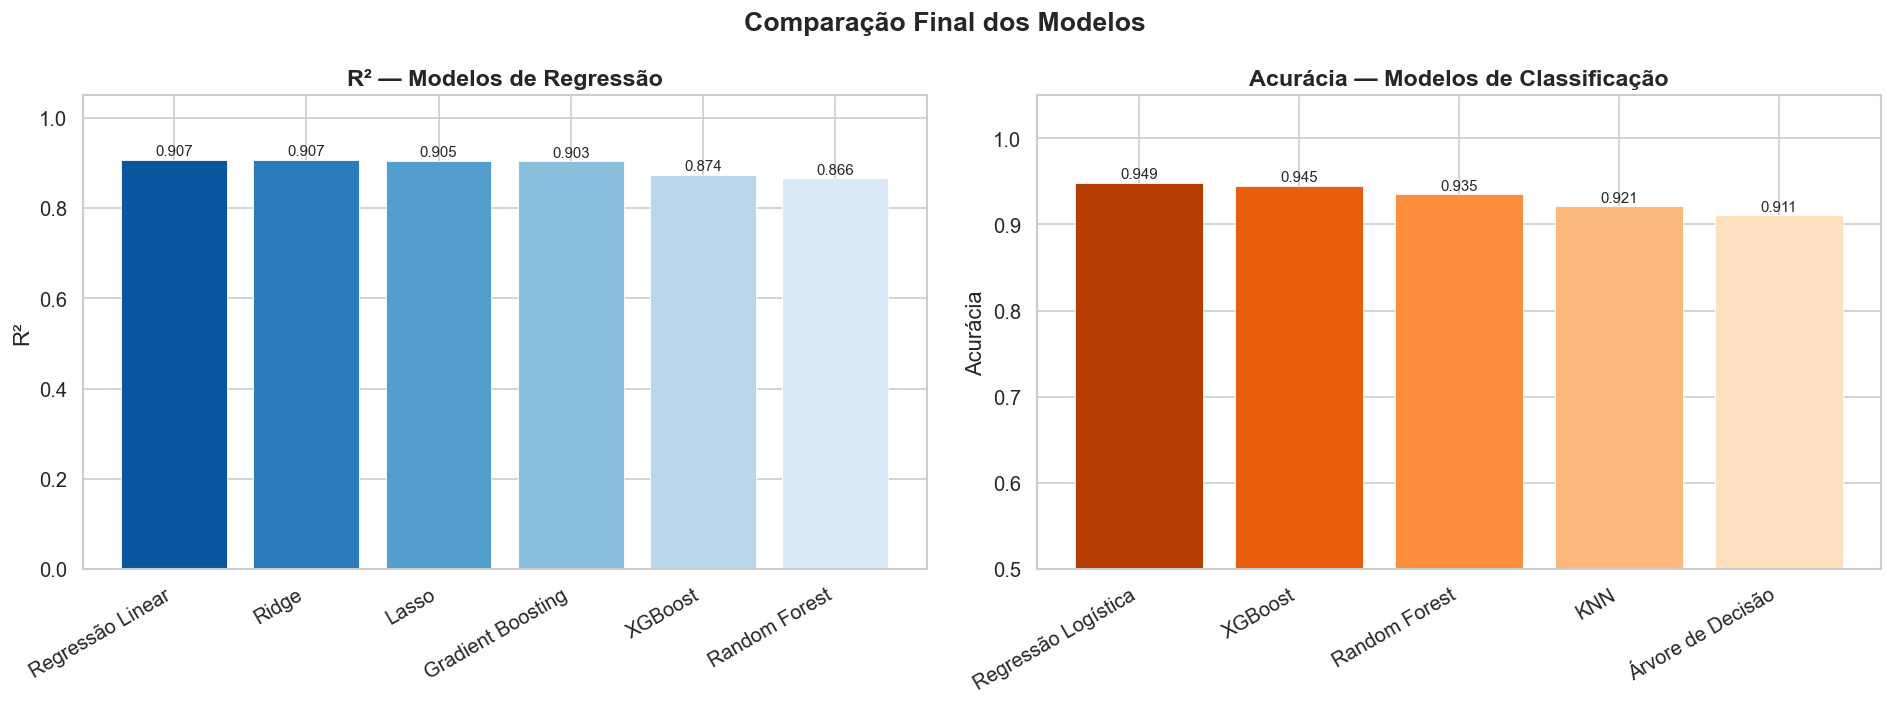

In [56]:
# ── Gráfico comparativo geral ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regressão — R²
ax = axes[0]
colors_r = sns.color_palette('Blues_r', len(reg_df))
bars = ax.bar(reg_df['Modelo'], reg_df['R²'], color=colors_r, edgecolor='white', linewidth=0.5)
ax.set_title('R² — Modelos de Regressão', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('R²')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
for bar, v in zip(bars, reg_df['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Classificação — Acurácia
ax2 = axes[1]
colors_c = sns.color_palette('Oranges_r', len(cls_df))
bars2 = ax2.bar(cls_df['Modelo'], cls_df['Acurácia'], color=colors_c, edgecolor='white', linewidth=0.5)
ax2.set_title('Acurácia — Modelos de Classificação', fontsize=14, fontweight='bold')
ax2.set_ylim(0.5, 1.05)
ax2.set_ylabel('Acurácia')
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')
for bar, v in zip(bars2, cls_df['Acurácia']):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparação Final dos Modelos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Conclusões

###  Análise Exploratória
- O dataset possui **81 variáveis** (43 categóricas, 38 numéricas) e **1460 imóveis**.
- `SalePrice` apresenta distribuição assimétrica à direita (skewness > 1), sendo necessária **transformação logarítmica** para modelagem.
- As variáveis mais correlacionadas com `SalePrice` são: **OverallQual, GrLivArea, GarageCars, TotalBsmtSF** e **1stFlrSF**.

###  Feature Engineering
- Criadas **10 novas features** como `TotalSF`, `TotalBath`, `HouseAge` e indicadores binários.
- Aplicada **log-transformação** nas features com alta assimetria.
- Encoding ordinal para variáveis de qualidade; One-Hot para demais categóricas.

###  Modelos Supervisionados
- **Regressão**: XGBoost e Gradient Boosting apresentaram os melhores R² (>0.90), superando Regressão Linear.
- **Classificação**: XGBoost e Random Forest atingiram acurácias próximas de 92%, com AUC-ROC >0.97.

###  Aprendizagem Não Supervisionada
- **PCA**: ~25 componentes capturam 95% da variância — significativa redução dimensional.
- **K-Means (k=4)**: identificou segmentos distintos — casas econômicas, padrão, superiores e de luxo.
- **LOF**: detectou ~5% de outliers — imóveis atípicos em preço ou características.
- **Apriori**: regras relevantes como `Alta qualidade + 3+ banheiros → Preço Luxo`.

---
*Projeto desenvolvido para a disciplina de Analise de dados — FAESA Centro Universitário.*